# RMSX Demonstration

This notebook includes everything you need to run **RMSX** and **Flipbook**. Just run each cell. You are encouraged to try different parameters and use your own trajectories directly within this notebook or by making a copy of it.


We'll cover:

1. Environment setup
2. Loading demo input files
3. Single-chain RMSX
4. Multi-chain RMSX
5. FlipBook snapshots (optional)
6. Interpreting results

> **Note:** Adjust file paths as needed for your machine. We reccomend not editing the first two cells, though.

## 1) Environment Setup

- **R** — used for heatmaps and RMSD/RMSF plots via `Rscript`.
- **ChimeraX** (optional) — used for FlipBook image generation.


### Quick Start

In [1]:
# One-click install for this kernel (no sudo; no Plotly required)
import sys, os, site, tempfile, urllib.request, subprocess, shutil

def _ensure_pip_in_kernel():
    try:
        import pip  # noqa: F401
        return
    except Exception:
        pass
    # Bootstrap pip into THIS kernel if it's missing
    print("Bootstrapping pip into this Jupyter kernel…")
    with tempfile.TemporaryDirectory() as td:
        gp = os.path.join(td, "get-pip.py")
        urllib.request.urlretrieve("https://bootstrap.pypa.io/get-pip.py", gp)
        subprocess.check_call([sys.executable, gp, "--user"])
    # Make sure user-site is importable in this process
    us = site.getusersitepackages()
    if us not in sys.path:
        sys.path.append(us)

_ensure_pip_in_kernel()

# Use Jupyter's %pip so installs target THIS kernel

%pip install -U pip wheel setuptools
%pip install -U "numpy>=1.26,<2.0" "pandas>=2.2,<2.3" "MDAnalysis>=2.6,<3" "scipy>=1.10" "plotly>=5"
%pip install -U "git+https://github.com/AntunesLab/rmsx.git@main" plotly>=5

# Optional: show Rscript (for plots) if available
import subprocess
RSCRIPT = os.environ.get("RSCRIPT", "Rscript")
try:
    out = subprocess.run([RSCRIPT, "-e", "cat(R.version.string)"] , capture_output=True, text=True)
    print(out.stdout or out.stderr or "Rscript OK")
except FileNotFoundError:
    print("⚠️ Rscript not found. Heatmap/RMSD/RMSF plots will be skipped until R is installed or RSCRIPT is set.")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
zsh:1: 5 not found
Note: you may need to restart the kernel to use updated packages.
R version 4.5.1 (2025-06-13)


In [2]:
# Imports & locate sample data
from pathlib import Path
import os, subprocess

from rmsx import run_rmsx, run_rmsx_flipbook, all_chain_rmsx, run_shift_flipbook
import rmsx

pkg_dir = Path(rmsx.__file__).resolve().parent

# Optional: set this to use your own dataset folder
# os.environ["RMSX_TEST_DIR"] = "/path/to/test_files"
env_override = os.environ.get("RMSX_TEST_DIR")

candidates = []
if env_override:
    candidates.append(Path(env_override))

candidates += [
    Path.cwd() / "test_files",              # next to this notebook
    Path.cwd() / "rmsx" / "test_files",     # if you cloned into ./rmsx
    pkg_dir / "test_files",                 # packaged tests (if included)
    pkg_dir.parent / "test_files",          # repo layout when running from source
]

test_dir = next((p for p in candidates if p.exists()), None)

# Last resort: clone repo to fetch sample data (does not affect installed package)
if not test_dir:
    REPO_URL = "https://github.com/AntunesLab/rmsx.git"
    REPO_DIR = Path.cwd() / "rmsx"
    if not REPO_DIR.exists():
        print("Cloning RMSX repo to retrieve sample data…")
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    test_dir = REPO_DIR / "test_files"
    if not test_dir.exists():
        raise FileNotFoundError("Couldn't locate test_files after cloning. Please report this issue.")

# Single-chain demo (Ubiquitin)
pdb_file   = (test_dir / "1UBQ.pdb").as_posix()
dcd_file   = (test_dir / "mon_sys.dcd").as_posix()
output_dir = (test_dir / "example_uqb").as_posix()

# Multi-chain demo (protease) — files live directly under test_files/
pdb_file_multi   = (test_dir / "protease_backbone.pdb").as_posix()
traj_file_multi  = (test_dir / "short_protease_backbone.dcd").as_posix()
output_dir_multi = (test_dir / "protease").as_posix()

print("Single-chain inputs:")
print("  PDB:", pdb_file)
print("  DCD:", dcd_file)
print("  out:", output_dir)

print("\nMulti-chain inputs:")
print("  PDB:", pdb_file_multi)
print("  DCD:", traj_file_multi)
print("  out:", output_dir_multi)


Single-chain inputs:
  PDB: /Users/finn/Documents/GitHub/rmsx/test_files/1UBQ.pdb
  DCD: /Users/finn/Documents/GitHub/rmsx/test_files/mon_sys.dcd
  out: /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb

Multi-chain inputs:
  PDB: /Users/finn/Documents/GitHub/rmsx/test_files/protease_backbone.pdb
  DCD: /Users/finn/Documents/GitHub/rmsx/test_files/short_protease_backbone.dcd
  out: /Users/finn/Documents/GitHub/rmsx/test_files/protease


*Windows users: if R isn’t on PATH, set `RSCRIPT` before running:*

In [3]:
import os
# os.environ["RSCRIPT"] = r"C:\\Program Files\\R\\R-4.4.1\\bin\\Rscript.exe"  # <- edit if needed
!pwd

/Users/finn/Documents/GitHub/rmsx


## 2) Load Demo Input Files

These come with the package as `test_files`. Rather than editing these we recocomend adding your paths in later cells. 

## 3) Single-Chain RMSX

`run_rmsx` computes per-slice RMSX and generates:
- RMSX heatmap
- RMSD time series
- RMSF per-residue

Edit `palette` and `chain_sele` as needed. (For the included Ubiquitin demo, the chain is `"7"`.)

/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


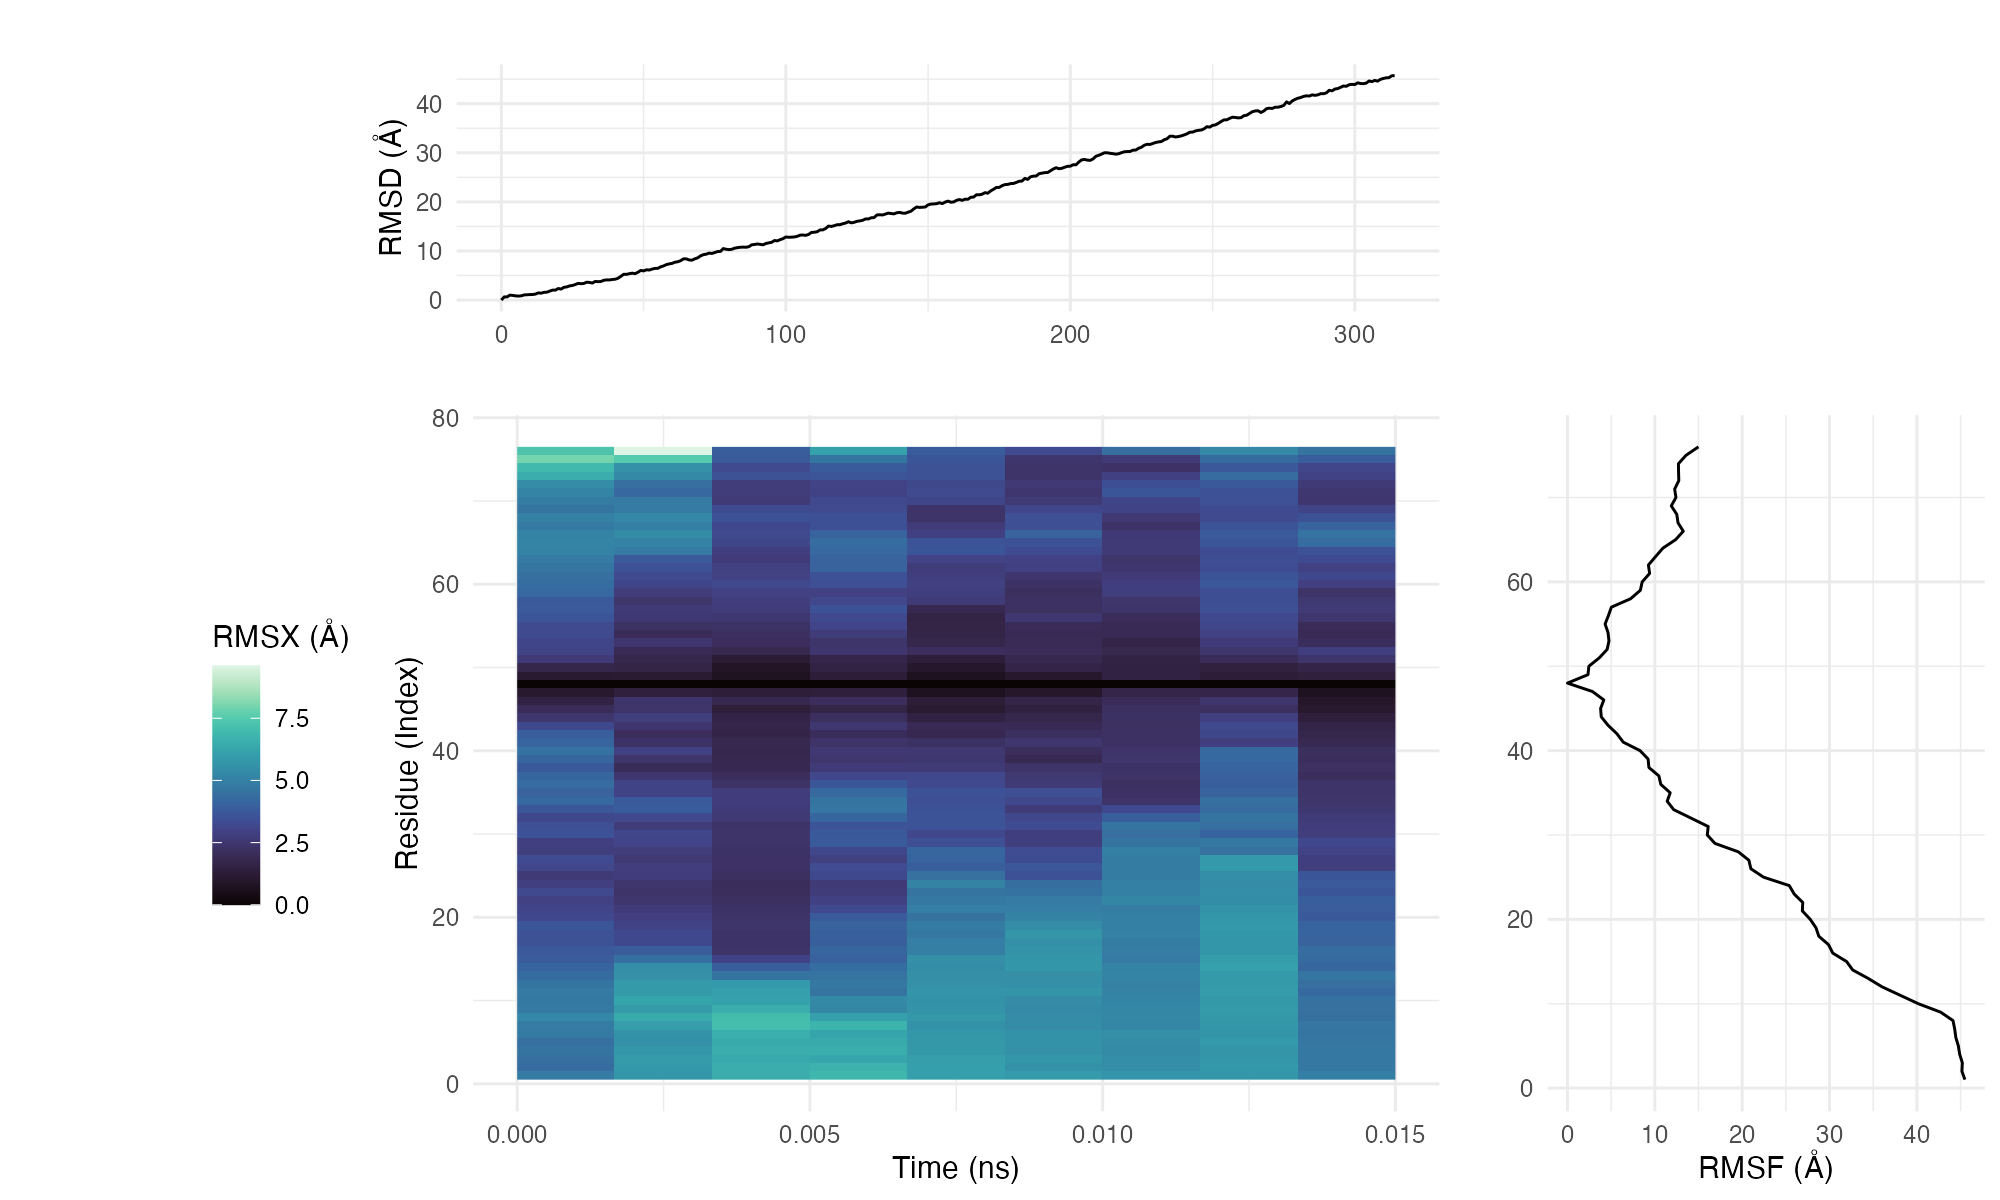

(     ResidueID  ChainID    TimeSlice      RMSX
 151         76        7  slice_2.dcd  9.616028
 74          75        7  slice_1.dcd  7.957497
 150         75        7  slice_2.dcd  7.495831,
      ResidueID  ChainID    TimeSlice  RMSX
 47          48        7  slice_1.dcd   0.0
 123         48        7  slice_2.dcd   0.0
 199         48        7  slice_3.dcd   0.0)

In [4]:
from rmsx import *


run_rmsx(
    topology_file=pdb_file,        # PDB or topology file
    trajectory_file=dcd_file,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=9,                  # Select number of slices and it will autogenerate slice size 
    slice_size=None,               # OR: select slice size and it will choose number of slices 
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="mako",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="7",                # Set to your chain ID or None to be prompted with available chain 
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True
)


In [ ]:
run_shift_flipbook(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=output_dir,
    num_slices=16,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=150,
    sync_color_scale=True,           # Useful when chains have very different RMSX values, True will force the same color key/scale to be used
    viewer="ChimeraX"
)


In [ ]:
!pip install biotite


In [ ]:
# Step 1: Imports and toy test data
import os
import numpy as np
import matplotlib.pyplot as plt

# For PDB I/O we’ll use MDAnalysis (same ecosystem as RMSX)
import MDAnalysis as mda

# --- Tiny helper: synthetic test matrix (frames x residues) ---

def make_dummy_metric_matrix(n_frames=5, n_residues=10, seed=0):
    """
    Create a small toy (frames x residues) matrix to test the pipeline.
    Values are just a smooth gradient + noise.
    """
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, n_frames)[:, None]  # shape (frames, 1)
    r = np.linspace(0, 1, n_residues)[None, :]  # shape (1, residues)

    base = t * r  # simple outer product
    noise = 0.1 * rng.standard_normal(size=(n_frames, n_residues))
    data = np.clip(base + noise, 0.0, 1.0)
    return data  # shape (frames, residues)

# Quick sanity check
dummy_matrix = make_dummy_metric_matrix(5, 10)
print("Dummy metric matrix shape:", dummy_matrix.shape)
print("Min, max:", dummy_matrix.min(), dummy_matrix.max())


In [ ]:
# Step 2: General heatmap function for a frames x residues matrix

def plot_metric_heatmap(metric_matrix,
                        frame_labels=None,
                        residue_labels=None,
                        title="Per-residue metric over time"):
    """
    metric_matrix: 2D array-like (n_frames x n_residues)
    frame_labels: 1D labels for frames (optional)
    residue_labels: 1D labels for residues (optional)
    """
    metric_matrix = np.asarray(metric_matrix)
    n_frames, n_residues = metric_matrix.shape

    if frame_labels is None:
        frame_labels = np.arange(n_frames)
    if residue_labels is None:
        residue_labels = np.arange(1, n_residues + 1)

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(metric_matrix.T, aspect='auto', origin='lower')
    # Note: transpose so y-axis is residue, x-axis is frame

    ax.set_xlabel("Frame index")
    ax.set_ylabel("Residue index")
    ax.set_title(title)

    fig.colorbar(im, ax=ax, label="Metric value")

    # Optional: thin ticks to avoid clutter for small tests
    ax.set_xticks(np.arange(n_frames))
    ax.set_yticks(np.arange(n_residues))
    ax.set_xticklabels(frame_labels)
    ax.set_yticklabels(residue_labels)

    plt.tight_layout()
    return fig, ax

# --- Test the heatmap with the dummy matrix ---
_ = plot_metric_heatmap(dummy_matrix,
                        title="Dummy metric (test heatmap)")


In [ ]:
# Step 3: Generic "metric → B-factor" Flipbook writer

def write_flipbook_pdbs_from_metric(
        topology_file,
        metric_matrix,
        output_dir,
        frame_indices=None,
        residue_mapping=None,
        overwrite=False
):
    """
    Write one PDB per frame, with metric values mapped to B-factors.

    Parameters
    ----------
    topology_file : str
        Path to a PDB (or other topology) that defines residues/atoms.
    metric_matrix : array-like, shape (n_frames, n_residues)
        Per-frame, per-residue metric values (e.g., LDDT, RMSX, shift).
    output_dir : str
        Directory where PDB snapshots will be written.
    frame_indices : list[int] or None
        Labels / indices to use in the output filenames.
        If None, use range(n_frames).
    residue_mapping : array-like or None
        Map from metric residue index (0..n_residues-1) to actual residue indices
        in the Universe. If None, assume 1-to-1 mapping to
        u.select_atoms("protein").residues in order.
    overwrite : bool
        If False, will raise if output_dir already exists.
    """
    metric_matrix = np.asarray(metric_matrix)
    n_frames, n_residues = metric_matrix.shape

    if frame_indices is None:
        frame_indices = list(range(n_frames))

    if len(frame_indices) != n_frames:
        raise ValueError("frame_indices must match metric_matrix.shape[0]")

    # Prepare output directory
    if os.path.exists(output_dir):
        if not overwrite:
            raise FileExistsError(
                f"Output dir {output_dir} already exists. "
                "Set overwrite=True to reuse."
            )
    else:
        os.makedirs(output_dir, exist_ok=True)

    # Load topology
    u = mda.Universe(topology_file)
    protein_residues = u.select_atoms("protein").residues

    if residue_mapping is None:
        if len(protein_residues) != n_residues:
            raise ValueError(
                f"Expected {n_residues} protein residues, found "
                f"{len(protein_residues)}. Provide residue_mapping."
            )
        residue_mapping = np.arange(n_residues)
    residue_mapping = np.asarray(residue_mapping)

    if residue_mapping.shape[0] != n_residues:
        raise ValueError("residue_mapping length must match n_residues")

    # --- Main loop: one output PDB per frame in metric_matrix ---
    for frame_idx, label in enumerate(frame_indices):
        # Copy current coordinates from the reference topology (no traj yet)
        # For a real trajectory we’d set coordinates from a frame;
        # here we use the same coordinates for all frames as a skeleton.
        # (we’re just testing the mapping logic)

        # Assign B-factor per residue based on metric_matrix[frame_idx]
        frame_values = metric_matrix[frame_idx]  # shape (n_residues,)

        # Reset B-factors
        u.atoms.tempfactors = 0.0

        # Map each residue’s metric to all atoms in that residue
        for metric_res_index, residue_index in enumerate(residue_mapping):
            val = float(frame_values[metric_res_index])
            res = protein_residues[residue_index]
            res.atoms.tempfactors = val

        # Write out
        out_path = os.path.join(output_dir, f"frame_{label:03d}.pdb")
        with mda.Writer(out_path, n_atoms=u.atoms.n_atoms) as w:
            w.write(u)


In [ ]:
# Step 3b: Simple test for the flipbook writer

test_topology = pdb_file   # <-- replace with your actual test PDB

# metric_matrix already defined above as dummy_matrix (5 x 10)
test_output_dir = "lddt_dummy_flipbook_test"

write_flipbook_pdbs_from_metric(
    topology_file=test_topology,
    metric_matrix=dummy_matrix,
    output_dir=test_output_dir,
    overwrite=True
)

print("Wrote files:", os.listdir(test_output_dir))


In [ ]:
# Step 4: High-level scaffold (metric-agnostic for now)

def lddt_heatmap_flipbook(
        topology_file,
        metric_matrix,
        output_dir,
        frame_indices=None,
        residue_labels=None,
        title="LDDT-like metric over time",
        overwrite=False
):
    """
    Simple benchmark-style function: makes a heatmap and a flipbook-style
    PDB sequence from a per-frame, per-residue metric matrix.

    Later, metric_matrix will be computed from actual LDDT.
    """
    metric_matrix = np.asarray(metric_matrix)
    n_frames, n_residues = metric_matrix.shape

    # 1) Heatmap
    _, _ = plot_metric_heatmap(metric_matrix,
                               frame_labels=frame_indices,
                               residue_labels=residue_labels,
                               title=title)

    # 2) Flipbook PDBs
    write_flipbook_pdbs_from_metric(
        topology_file=topology_file,
        metric_matrix=metric_matrix,
        output_dir=output_dir,
        frame_indices=frame_indices,
        residue_mapping=None,
        overwrite=overwrite
    )

    print(f"Heatmap created and flipbook PDBs written to {output_dir}")


In [ ]:
# Step 4b: Test the scaffold with dummy metric

test_output_dir = "lddt_dummy_benchmark"
frame_labels = list(range(dummy_matrix.shape[0]))
res_labels = list(range(1, dummy_matrix.shape[1] + 1))

lddt_heatmap_flipbook(
    topology_file=test_topology,
    metric_matrix=dummy_matrix,
    output_dir=test_output_dir,
    frame_indices=frame_labels,
    residue_labels=res_labels,
    title="Dummy metric (LDDT scaffold)",
    overwrite=True
)


In [ ]:
# Cell 1
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda

try:
    import biotite.structure as struc
    from biotite.structure import lddt
    _BIO_AVAILABLE = True
except ImportError:
    _BIO_AVAILABLE = False
    print("Warning: Biotite not found. lDDT calculation will fail or fallback.")

print("Biotite available:", _BIO_AVAILABLE)


In [ ]:
# Cell 2: (updated)
import numpy as np
import MDAnalysis as mda
from MDAnalysis.topology.guessers import guess_atom_element
import biotite.structure as struc
from biotite.structure import lddt

def compute_lddt_over_time_with_guess(topology_file,
                                      trajectory_file,
                                      selection="protein and name CA",
                                      reference_frame=0,
                                      stride=1,
                                      end_frame=None,
                                      aggregation="residue",
                                      inclusion_radius=15.0):
    """
    Compute a per‐frame × per‐residue lDDT matrix.
    Ensures element information is present in MDAnalysis Universe.
    """
    u = mda.Universe(topology_file, trajectory_file)
    # Guess elements if missing
    if not hasattr(u.atoms, 'elements') or u.atoms.elements is None:
        guessed = np.array([guess_atom_element(name) for name in u.atoms.names], dtype=object)
        u.add_TopologyAttr('elements', guessed)
        print("Added guessed element attribute to Universe.")

    sel = u.select_atoms(selection)
    u.trajectory[reference_frame]
    ref_coords = sel.positions.copy()


    ref_aa = struc.AtomArray(ref_coords.shape[0])
    ref_aa.coord = ref_coords

    # Set required annotations
    ref_aa.set_annotation("element", sel.elements)
    ref_aa.set_annotation("atom_name", sel.names)
    ref_aa.set_annotation("chain_id", sel.chainIDs)
    ref_aa.set_annotation("res_id", sel.resids)




    if end_frame is None:
        end_frame = len(u.trajectory)
    frames = list(range(reference_frame, end_frame, stride))
    n_frames = len(frames)
    n_residues = len(sel.residues)

    lddt_matrix = np.zeros((n_frames, n_residues), dtype=float)
    for i, fr in enumerate(frames):
        u.trajectory[fr]
        mob_coords = sel.positions.copy()
        mob_aa = struc.AtomArray(mob_coords,
                                 element=sel.elements,
                                 atom_name=sel.names,
                                 chain_id=sel.chainIDs,
                                 res_id=sel.resids,
                                 model=0)
        scores = lddt(ref_aa, mob_aa,
                      aggregation=aggregation,
                      inclusion_radius=inclusion_radius)
        lddt_matrix[i, :] = scores

    return lddt_matrix, frames


In [ ]:
# Cell 3
def summary_lddt_matrix(lddt_mat, frame_idx=None, residue_labels=None, top_n=10):
    n_frames, n_residues = lddt_mat.shape
    print(f"Matrix shape: {n_frames} frames × {n_residues} residues")
    print(f"Overall: min={lddt_mat.min():.3f}, mean={lddt_mat.mean():.3f}, max={lddt_mat.max():.3f}")

    mean_by_res = lddt_mat.mean(axis=0)
    if residue_labels is None:
        residue_labels = np.arange(1, n_residues+1)
    print("\nMean per residue (first {top_n}):")
    for lbl, m in zip(residue_labels[:top_n], mean_by_res[:top_n]):
        print(f"  Residue {lbl}: {m:.3f}")
    if n_residues > top_n:
        print("  …")

    mean_by_frame = lddt_mat.mean(axis=1)
    if frame_idx is None:
        frame_idx = list(range(n_frames))
    print("\nMean per frame (first {top_n}):")
    for fr, m in zip(frame_idx[:top_n], mean_by_frame[:top_n]):
        print(f"  Frame {fr}: {m:.3f}")
    if n_frames > top_n:
        print("  …")

def plot_lddt_heatmap(lddt_mat,
                      frame_idx=None,
                      residue_labels=None,
                      figsize=(8, 6),
                      cmap="viridis",
                      title="Per-residue lDDT over time"):
    if frame_idx is None:
        frame_idx = np.arange(lddt_mat.shape[0])
    if residue_labels is None:
        residue_labels = np.arange(1, lddt_mat.shape[1] + 1)

    plt.figure(figsize=figsize)
    plt.imshow(lddt_mat.T, aspect="auto", origin="lower",
               cmap=cmap,
               extent=[frame_idx[0], frame_idx[-1],
                       residue_labels[0], residue_labels[-1]])
    plt.colorbar(label="lDDT score")
    plt.xlabel("Frame index")
    plt.ylabel("Residue index")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 4: Replace these paths with your actual files
topology_file  = pdb_file
trajectory_file = dcd_file

# Parameters
selection      = "protein and name CA"
reference_frame= 0
stride         = 5
inclusion_radius=15.0

# Compute
lddt_mat, frames = compute_lddt_over_time_with_guess(
    topology_file,
    trajectory_file,
    selection=selection,
    reference_frame=reference_frame,
    stride=stride,
    inclusion_radius=inclusion_radius
)

# Summary
summary_lddt_matrix(lddt_mat,
                    frame_idx=frames)

# Plot
plot_lddt_heatmap(lddt_mat,
                  frame_idx=frames,
                  title="lDDT over time (frames × residues)")


In [ ]:
#!/usr/bin/env python3
"""
lddt_heatmap.py

Compute a per-residue lDDT over time from a trajectory and a reference PDB,
and plot it as a heatmap.

We implement a CA-only, superposition-free lDDT-style score:

  - For each residue i in the reference:
      * Find all other residues j whose CA-CA distance in the reference
        is < inclusion_radius (default 15 Å).
      * For each frame, compare CA-CA distances d_model(i,j) vs d_ref(i,j)
        and check |d_model - d_ref| < tau for multiple thresholds tau.
      * The per-residue lDDT is the mean over thresholds of the fraction of
        neighbors whose distance is preserved at each threshold.

This gives a per-residue lDDT(t) that is:
  - local
  - superposition-free
  - CA-only approximation to full lDDT
"""

import argparse
import numpy as np
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array


def compute_reference_distances(universe, selection="protein and name CA",
                                inclusion_radius=15.0):
    """
    Precompute reference CA-CA distances and neighbor lists per residue.

    Parameters
    ----------
    universe : MDAnalysis.Universe
        Universe containing the reference structure (PDB).
    selection : str
        Atom selection string for which lDDT is computed. Default is CA-only.
    inclusion_radius : float
        Maximum reference distance (Å) for residue pairs to be considered neighbors.

    Returns
    -------
    ref_dists : np.ndarray, shape (N, N)
        Pairwise CA-CA distances in the reference.
    neighbor_indices : list of np.ndarray
        neighbor_indices[i] = array of residue indices j that are neighbors of i.
    residues : MDAnalysis.core.groups.ResidueGroup
        Residues corresponding to the selected atoms.
    """
    # Select CA atoms and associated residues
    ca_atoms = universe.select_atoms(selection)
    residues = ca_atoms.residues
    n_res = len(residues)
    if n_res == 0:
        raise ValueError(f"No residues found with selection: '{selection}'")

    # Use CA coordinates for each residue (1 CA per residue)
    # Assumes 1 CA per residue; if multiple CA per residue something is wrong.
    ca_positions = ca_atoms.positions  # shape (N, 3)
    if ca_positions.shape[0] != n_res:
        # Defensive check: unusual topology
        raise ValueError(
            "Number of selected atoms != number of residues; "
            "this script assumes one CA per residue."
        )

    # Compute full CA-CA distance matrix for the reference
    ref_dists = distance_array(ca_positions, ca_positions)  # (N, N)

    # Build neighbor list per residue (exclude self)
    neighbor_indices = []
    for i in range(n_res):
        mask = (ref_dists[i] < inclusion_radius)
        mask[i] = False  # exclude self
        neighbors = np.where(mask)[0]
        neighbor_indices.append(neighbors)

    return ref_dists, neighbor_indices, residues


def compute_lddt_time_series(universe, ref_dists, neighbor_indices,
                             selection="protein and name CA",
                             thresholds=(0.5, 1.0, 2.0, 4.0)):
    """
    Compute per-residue lDDT for each frame in the trajectory.

    Parameters
    ----------
    universe : MDAnalysis.Universe
        Universe with topology + trajectory.
    ref_dists : np.ndarray, shape (N, N)
        Reference CA-CA distance matrix.
    neighbor_indices : list of np.ndarray
        neighbor_indices[i] = neighbors of residue i (indices).
    selection : str
        Atom selection used to match CA atoms in the trajectory.
    thresholds : tuple of float
        Distance-difference thresholds (Å) used to define preserved distances.

    Returns
    -------
    lddt_matrix : np.ndarray, shape (n_frames, n_res)
        lDDT score for each residue at each frame.
    times : np.ndarray, shape (n_frames,)
        Trajectory time for each frame (ps), or frame index if time is unavailable.
    residues : MDAnalysis.core.groups.ResidueGroup
        Residues corresponding to the selected atoms.
    """
    ca_atoms = universe.select_atoms(selection)
    residues = ca_atoms.residues
    n_res = len(residues)
    n_frames = universe.trajectory.n_frames

    if ca_atoms.n_atoms != n_res:
        raise ValueError(
            "Number of selected atoms != number of residues; "
            "this script assumes one CA per residue."
        )

    # Prepare output array: frames x residues
    lddt_matrix = np.zeros((n_frames, n_res), dtype=float)
    times = np.zeros(n_frames, dtype=float)

    thresholds = np.array(thresholds, dtype=float)
    n_thr = len(thresholds)

    # Iterate over trajectory
    for fi, ts in enumerate(universe.trajectory):
        times[fi] = ts.time if ts.time is not None else fi

        # Current CA coordinates
        ca_positions = ca_atoms.positions
        # Distance matrix for this frame
        dists = distance_array(ca_positions, ca_positions)

        # For each residue, compute lDDT
        for i in range(n_res):
            neigh = neighbor_indices[i]
            if neigh.size == 0:
                # No neighbors within radius; set NaN to indicate undefined
                lddt_matrix[fi, i] = np.nan
                continue

            # Reference distances and model distances for residue i
            d_ref = ref_dists[i, neigh]       # shape (k,)
            d_mod = dists[i, neigh]           # shape (k,)
            diff = np.abs(d_mod - d_ref)      # shape (k,)

            # For each threshold, compute fraction of preserved distances
            # diff[None, :] -> shape (1, k); thresholds[:, None] -> (n_thr, 1)
            preserved = diff[None, :] < thresholds[:, None]   # (n_thr, k)
            frac_preserved = preserved.sum(axis=1) / float(neigh.size)  # (n_thr,)

            # lDDT for this residue/frame = mean over thresholds
            lddt_matrix[fi, i] = frac_preserved.mean()

    return lddt_matrix, times, residues


def plot_lddt_heatmap(lddt_matrix, times, residues,
                      output_file="lddt_heatmap.png",
                      time_units="ps",
                      vmin=0.0, vmax=1.0):
    """
    Plot a heatmap of lDDT (time x residue).

    Parameters
    ----------
    lddt_matrix : np.ndarray, shape (n_frames, n_res)
        lDDT scores.
    times : np.ndarray, shape (n_frames,)
        Time values (e.g. ps).
    residues : MDAnalysis.core.groups.ResidueGroup
        Residues corresponding to columns of lddt_matrix.
    output_file : str
        Path to save the heatmap image.
    time_units : str
        Label for the time axis (e.g. "ps", "ns", "frames").
    vmin, vmax : float
        Color scale limits for the heatmap.
    """
    n_frames, n_res = lddt_matrix.shape

    # Build x-axis as residue IDs (or simple indices)
    # You can switch to resid or resindex depending on what you prefer.
    res_ids = [res.resid for res in residues]

    # If times are all zero (unpopulated), switch to frame index
    if np.all(times == 0):
        y_vals = np.arange(n_frames)
        y_label = "Frame"
    else:
        y_vals = times
        y_label = f"Time ({time_units})"

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # imshow expects [Y, X] = [frames, residues]
    # aspect="auto" lets it stretch nicely.
    im = ax.imshow(lddt_matrix,
                   origin="lower",
                   aspect="auto",
                   interpolation="nearest",
                   vmin=vmin, vmax=vmax)

    # Axis labels and ticks
    ax.set_xlabel("Residue")
    ax.set_ylabel(y_label)

    # Optionally show fewer residue ticks if many residues
    if n_res <= 50:
        ax.set_xticks(np.arange(n_res))
        ax.set_xticklabels(res_ids, rotation=90)
    else:
        # Sparse tick labeling
        step = max(1, n_res // 20)
        idxs = np.arange(0, n_res, step)
        ax.set_xticks(idxs)
        ax.set_xticklabels([res_ids[i] for i in idxs], rotation=90)

    # Y-axis ticks: similar sparsity control
    if len(y_vals) <= 20:
        ax.set_yticks(np.arange(len(y_vals)))
        ax.set_yticklabels([f"{v:.2f}" for v in y_vals])
    else:
        step = max(1, len(y_vals) // 10)
        idxs = np.arange(0, len(y_vals), step)
        ax.set_yticks(idxs)
        ax.set_yticklabels([f"{y_vals[i]:.2f}" for i in idxs])

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("lDDT (CA-only)")

    fig.tight_layout()
    fig.savefig(output_file, dpi=300)
    plt.close(fig)


def main():
    parser = argparse.ArgumentParser(
        description="Compute per-residue CA-only lDDT over time and plot a heatmap."
    )
    parser.add_argument("-p", "--pdb", required=True,
                        help="Reference PDB file.")
    parser.add_argument("-t", "--traj", required=True,
                        help="Trajectory file (e.g., DCD, XTC, etc.).")
    parser.add_argument("-o", "--out", default="lddt_heatmap.png",
                        help="Output heatmap image file (default: lddt_heatmap.png).")
    parser.add_argument("--selection", default="protein and name CA",
                        help="Atom selection for lDDT computation "
                             "(default: 'protein and name CA').")
    parser.add_argument("--radius", type=float, default=15.0,
                        help="Inclusion radius (Å) for defining local neighbors (default: 15.0).")
    parser.add_argument("--thresholds", type=float, nargs="+",
                        default=[0.5, 1.0, 2.0, 4.0],
                        help="Distance-difference thresholds (Å) for lDDT "
                             "(default: 0.5 1.0 2.0 4.0).")
    parser.add_argument("--time-units", default="ps",
                        help="Units label for the time axis (default: ps).")

    args = parser.parse_args()

    # Load reference structure (PDB) and trajectory
    # Universe with trajectory
    u = mda.Universe(args.pdb, args.traj)

    # Separate reference Universe (PDB only) to ensure we use the original coordinates
    ref_u = mda.Universe(args.pdb)

    # Precompute reference distances and neighbor lists
    ref_dists, neighbor_indices, residues = compute_reference_distances(
        ref_u,
        selection=args.selection,
        inclusion_radius=args.radius
    )

    # Compute lDDT over time
    lddt_matrix, times, residues_traj = compute_lddt_time_series(
        u,
        ref_dists,
        neighbor_indices,
        selection=args.selection,
        thresholds=tuple(args.thresholds)
    )

    # Sanity check: same residue ordering
    # (simple check on resid, you can tighten if needed)
    if len(residues) != len(residues_traj):
        raise RuntimeError("Mismatch in residue counts between reference and trajectory.")

    # Plot heatmap
    plot_lddt_heatmap(lddt_matrix, times, residues_traj,
                      output_file=args.out,
                      time_units=args.time_units)


if __name__ == "__main__":
    main()



Try this again:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.lib.distances import distance_array


def compute_reference_distances(universe,
                                selection="protein and name CA",
                                inclusion_radius=15.0):
    """
    Precompute reference CA-CA distances and neighbor lists per residue.

    Parameters
    ----------
    universe : MDAnalysis.Universe
        Universe containing the reference structure (PDB only).
    selection : str
        Atom selection string for which lDDT is computed. Default is CA-only.
    inclusion_radius : float
        Maximum reference distance (Å) for residue pairs to be considered neighbors.

    Returns
    -------
    ref_dists : np.ndarray, shape (N, N)
        Pairwise CA-CA distances in the reference.
    neighbor_indices : list of np.ndarray
        neighbor_indices[i] = array of residue indices j that are neighbors of i.
    residues : MDAnalysis.core.groups.ResidueGroup
        Residues corresponding to the selected atoms.
    """
    ca_atoms = universe.select_atoms(selection)
    residues = ca_atoms.residues
    n_res = len(residues)

    if n_res == 0:
        raise ValueError(f"No residues found with selection: '{selection}'")

    ca_positions = ca_atoms.positions  # shape (N, 3)
    if ca_positions.shape[0] != n_res:
        raise ValueError(
            "Number of selected atoms != number of residues; "
            "this function assumes one CA per residue."
        )

    # Full CA-CA distance matrix for the reference
    ref_dists = distance_array(ca_positions, ca_positions)  # (N, N)

    # Build neighbor list per residue (exclude self)
    neighbor_indices = []
    for i in range(n_res):
        mask = (ref_dists[i] < inclusion_radius)
        mask[i] = False  # exclude self
        neighbors = np.where(mask)[0]
        neighbor_indices.append(neighbors)

    return ref_dists, neighbor_indices, residues


def compute_lddt_time_series(universe,
                             ref_dists,
                             neighbor_indices,
                             selection="protein and name CA",
                             thresholds=(0.5, 1.0, 2.0, 4.0)):
    """
    Compute per-residue CA-only lDDT for each frame in the trajectory.

    Parameters
    ----------
    universe : MDAnalysis.Universe
        Universe with topology + trajectory.
    ref_dists : np.ndarray, shape (N, N)
        Reference CA-CA distance matrix.
    neighbor_indices : list of np.ndarray
        neighbor_indices[i] = neighbors of residue i (indices).
    selection : str
        Atom selection used to match CA atoms in the trajectory.
    thresholds : tuple of float
        Distance-difference thresholds (Å) used to define preserved distances.

    Returns
    -------
    lddt_matrix : np.ndarray, shape (n_frames, n_res)
        lDDT score for each residue at each frame.
    times : np.ndarray, shape (n_frames,)
        Trajectory time for each frame (ps), or frame index if time is unavailable.
    residues : MDAnalysis.core.groups.ResidueGroup
        Residues corresponding to the selected atoms.
    """
    ca_atoms = universe.select_atoms(selection)
    residues = ca_atoms.residues
    n_res = len(residues)
    n_frames = universe.trajectory.n_frames

    if ca_atoms.n_atoms != n_res:
        raise ValueError(
            "Number of selected atoms != number of residues; "
            "this function assumes one CA per residue."
        )

    lddt_matrix = np.zeros((n_frames, n_res), dtype=float)
    times = np.zeros(n_frames, dtype=float)

    thresholds = np.array(thresholds, dtype=float)
    n_thr = len(thresholds)

    for fi, ts in enumerate(universe.trajectory):
        times[fi] = ts.time if ts.time is not None else fi

        ca_positions = ca_atoms.positions
        dists = distance_array(ca_positions, ca_positions)

        for i in range(n_res):
            neigh = neighbor_indices[i]
            if neigh.size == 0:
                lddt_matrix[fi, i] = np.nan
                continue

            d_ref = ref_dists[i, neigh]   # (k,)
            d_mod = dists[i, neigh]       # (k,)
            diff = np.abs(d_mod - d_ref)  # (k,)

            preserved = diff[None, :] < thresholds[:, None]   # (n_thr, k)
            frac_preserved = preserved.sum(axis=1) / float(neigh.size)  # (n_thr,)

            lddt_matrix[fi, i] = frac_preserved.mean()

    return lddt_matrix, times, residues


def plot_lddt_heatmap(lddt_matrix,
                      times,
                      residues,
                      output_file=None,
                      time_units="ps",
                      vmin=0.0,
                      vmax=1.0):
    """
    Plot a heatmap of lDDT with **time on the x-axis** and **residue on the y-axis**.

    Parameters
    ----------
    lddt_matrix : np.ndarray, shape (n_frames, n_res)
        lDDT scores.
    times : np.ndarray, shape (n_frames,)
        Time values (e.g. ps).
    residues : MDAnalysis.core.groups.ResidueGroup
        Residues corresponding to columns of lddt_matrix.
    output_file : str or None
        If given, save the heatmap to this path; otherwise just display it.
    time_units : str
        Label for the time axis (e.g. "ps", "ns", "frames").
    vmin, vmax : float
        Color scale limits for the heatmap.
    """
    n_frames, n_res = lddt_matrix.shape
    res_ids = [res.resid for res in residues]

    # Decide what to use for the x-axis (time vs frame index)
    if np.all(times == 0):
        x_vals = np.arange(n_frames)
        x_label = "Frame"
    else:
        x_vals = times
        x_label = f"Time ({time_units})"

    fig, ax = plt.subplots(figsize=(10, 6))

    # TRANSPOSE here: now rows = residues, columns = frames/time
    im = ax.imshow(lddt_matrix.T,
                   origin="lower",
                   aspect="auto",
                   interpolation="nearest",
                   vmin=vmin, vmax=vmax)

    # Labels
    ax.set_xlabel(x_label)
    ax.set_ylabel("Residue")

    # X ticks (time / frames)
    if len(x_vals) <= 20:
        ax.set_xticks(np.arange(len(x_vals)))
        ax.set_xticklabels([f"{v:.2f}" for v in x_vals], rotation=45, ha="right")
    else:
        step = max(1, len(x_vals) // 10)
        idxs = np.arange(0, len(x_vals), step)
        ax.set_xticks(idxs)
        ax.set_xticklabels([f"{x_vals[i]:.2f}" for i in idxs],
                           rotation=45, ha="right")

    # Y ticks (residues)
    if n_res <= 50:
        ax.set_yticks(np.arange(n_res))
        ax.set_yticklabels(res_ids)
    else:
        step = max(1, n_res // 20)
        idxs = np.arange(0, n_res, step)
        ax.set_yticks(idxs)
        ax.set_yticklabels([res_ids[i] for i in idxs])

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("lDDT (CA-only)")

    fig.tight_layout()

    if output_file is not None:
        fig.savefig(output_file, dpi=300)
        plt.close(fig)
    else:
        plt.show()



In [ ]:
# Edit these paths for your system
pdb_path = pdb_file
traj_path = dcd_file

# Load trajectory + topology
u = mda.Universe(pdb_path, traj_path)

# Separate reference universe (PDB only) so we use the original coordinates
ref_u = mda.Universe(pdb_path)

# Parameters (you can tweak these)
selection = "protein and name CA"   # or "protein and backbone"
inclusion_radius = 15.0             # Å
thresholds = (0.5, 1.0, 2.0, 4.0)   # Å
time_units = "ps"                   # change if you rescale times

# 1) Precompute reference distances + neighbor lists
ref_dists, neighbor_indices, ref_residues = compute_reference_distances(
    ref_u,
    selection=selection,
    inclusion_radius=inclusion_radius,
)

# 2) Compute per-residue lDDT over time
lddt_matrix, times, traj_residues = compute_lddt_time_series(
    u,
    ref_dists,
    neighbor_indices,
    selection=selection,
    thresholds=thresholds,
)

# Simple sanity check that residues match (by count)
if len(ref_residues) != len(traj_residues):
    raise RuntimeError("Residue count mismatch between reference and trajectory.")

# 3) Plot the heatmap inline
plot_lddt_heatmap(
    lddt_matrix,
    times,
    traj_residues,
    output_file=None,   # show in notebook; set to a filename to save instead
    time_units=time_units,
    vmin=0.0,
    vmax=1.0,
)


In [ ]:
# Per-residue time-averaged lDDT
mean_lddt_per_res = np.nanmean(lddt_matrix, axis=0)

plt.figure(figsize=(10, 3))
plt.plot([res.resid for res in traj_residues], mean_lddt_per_res, marker=".")
plt.xlabel("Residue")
plt.ylabel("Mean lDDT")
plt.ylim(0, 1)
plt.title("Time-averaged per-residue lDDT")
plt.tight_layout()
plt.show()


In [ ]:
!Rscript -e 'user<-Sys.getenv("R_LIBS_USER"); if(user=="") user<-file.path(Sys.getenv("HOME"),"R","library"); dir.create(user,recursive=TRUE,showWarnings=FALSE); .libPaths(c(user,.libPaths())); install.packages(c("ggplot2","viridis","dplyr","tidyr","stringr","readr","gridExtra"), lib=user, dependencies=c("Depends","Imports","LinkingTo"))'


## 4) Multi-Chain RMSX

`all_chain_rmsx` runs RMSX for **every** chain in the topology. If you set `sync_color_scale=True`,
all plots share a consistent colorbar range.

In [ ]:
all_chain_rmsx(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=output_dir,
    num_slices=12,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=None,
    sync_color_scale=True           # Useful when chains have very different RMSX values, True will force the same color key/scale to be used
)

## 5) FlipBook (optional)

FlipBook maps RMSX values (stored in the PDB B-factor column) onto 3D structures and lays out snapshots side-by-side.

/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


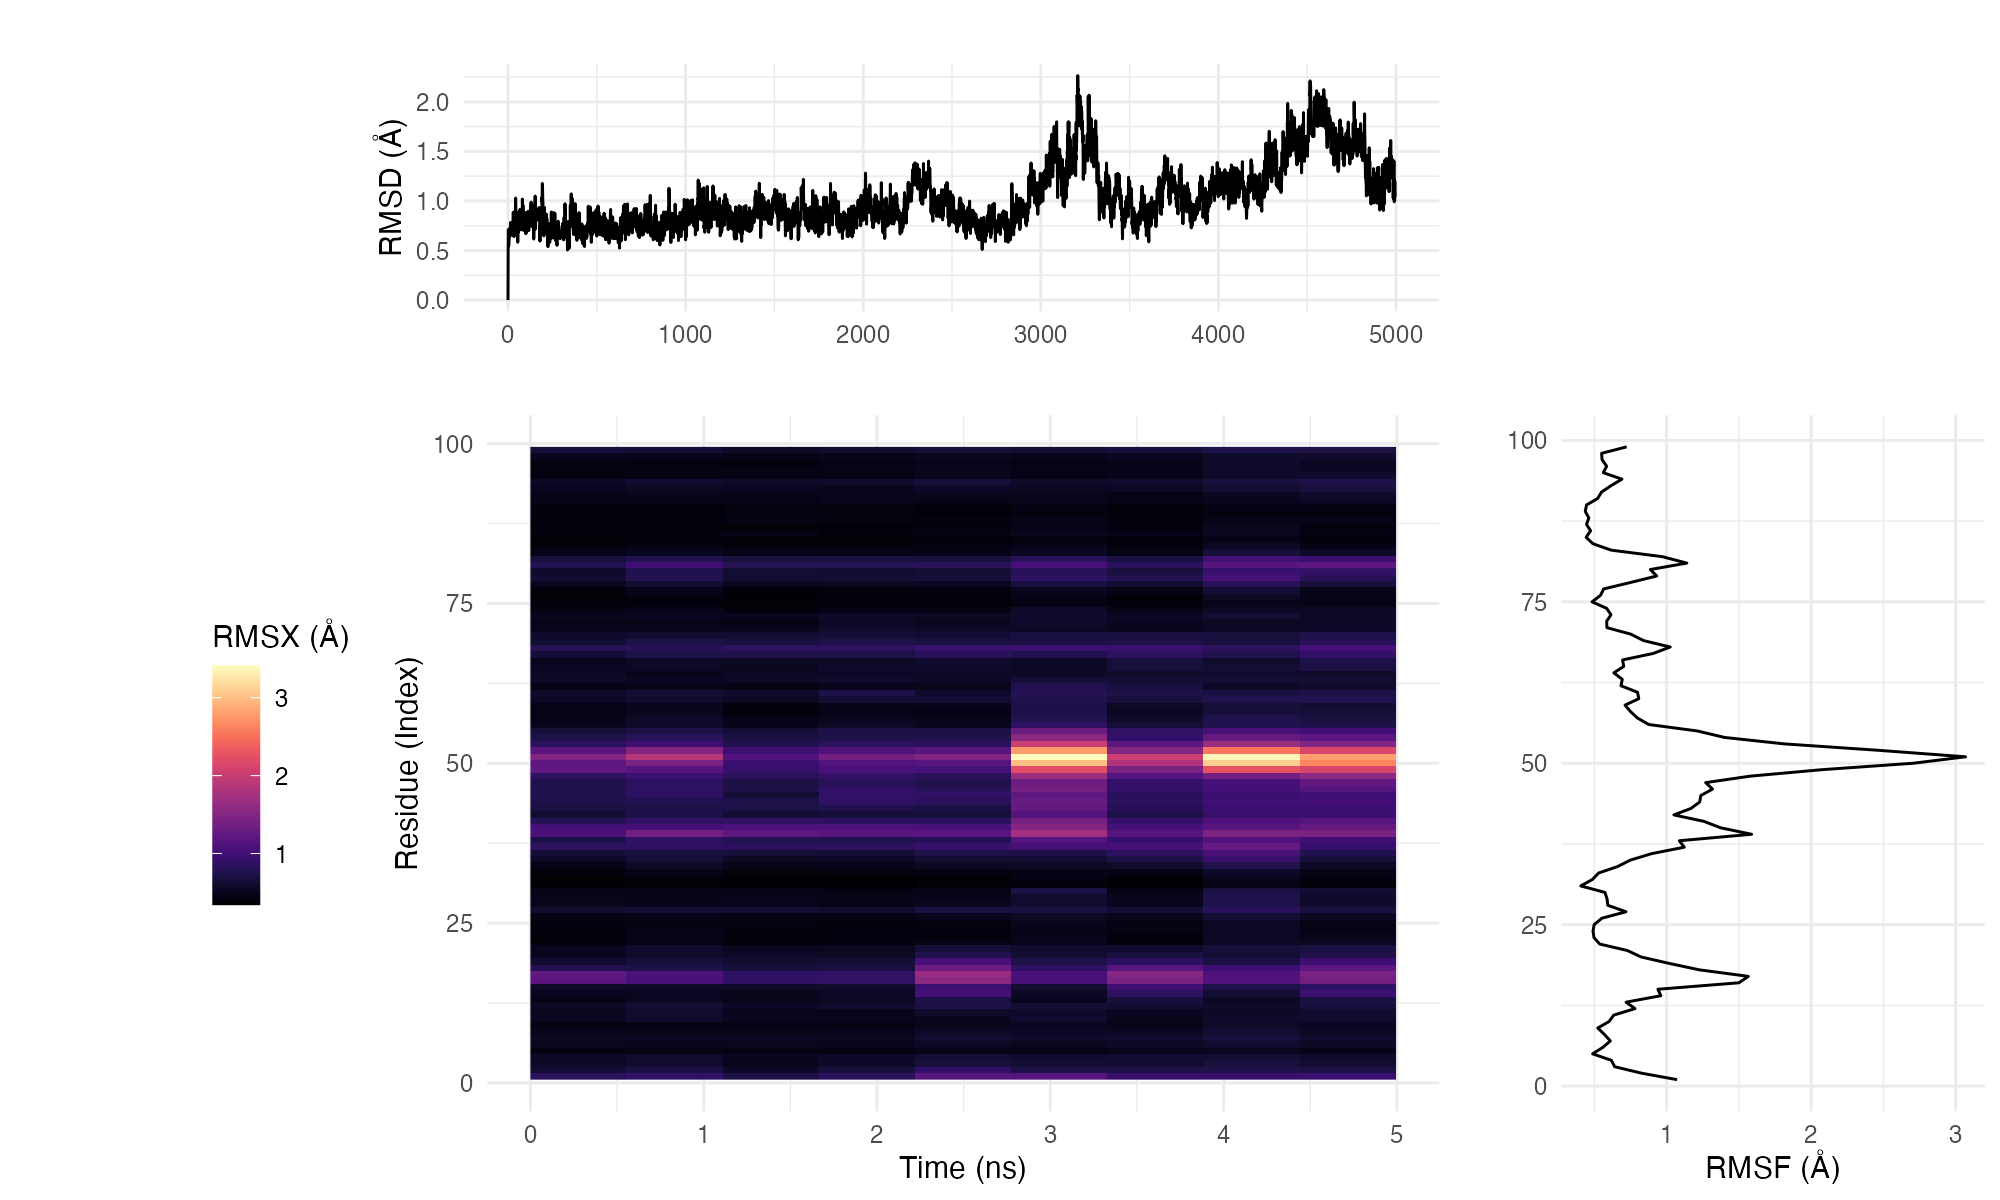

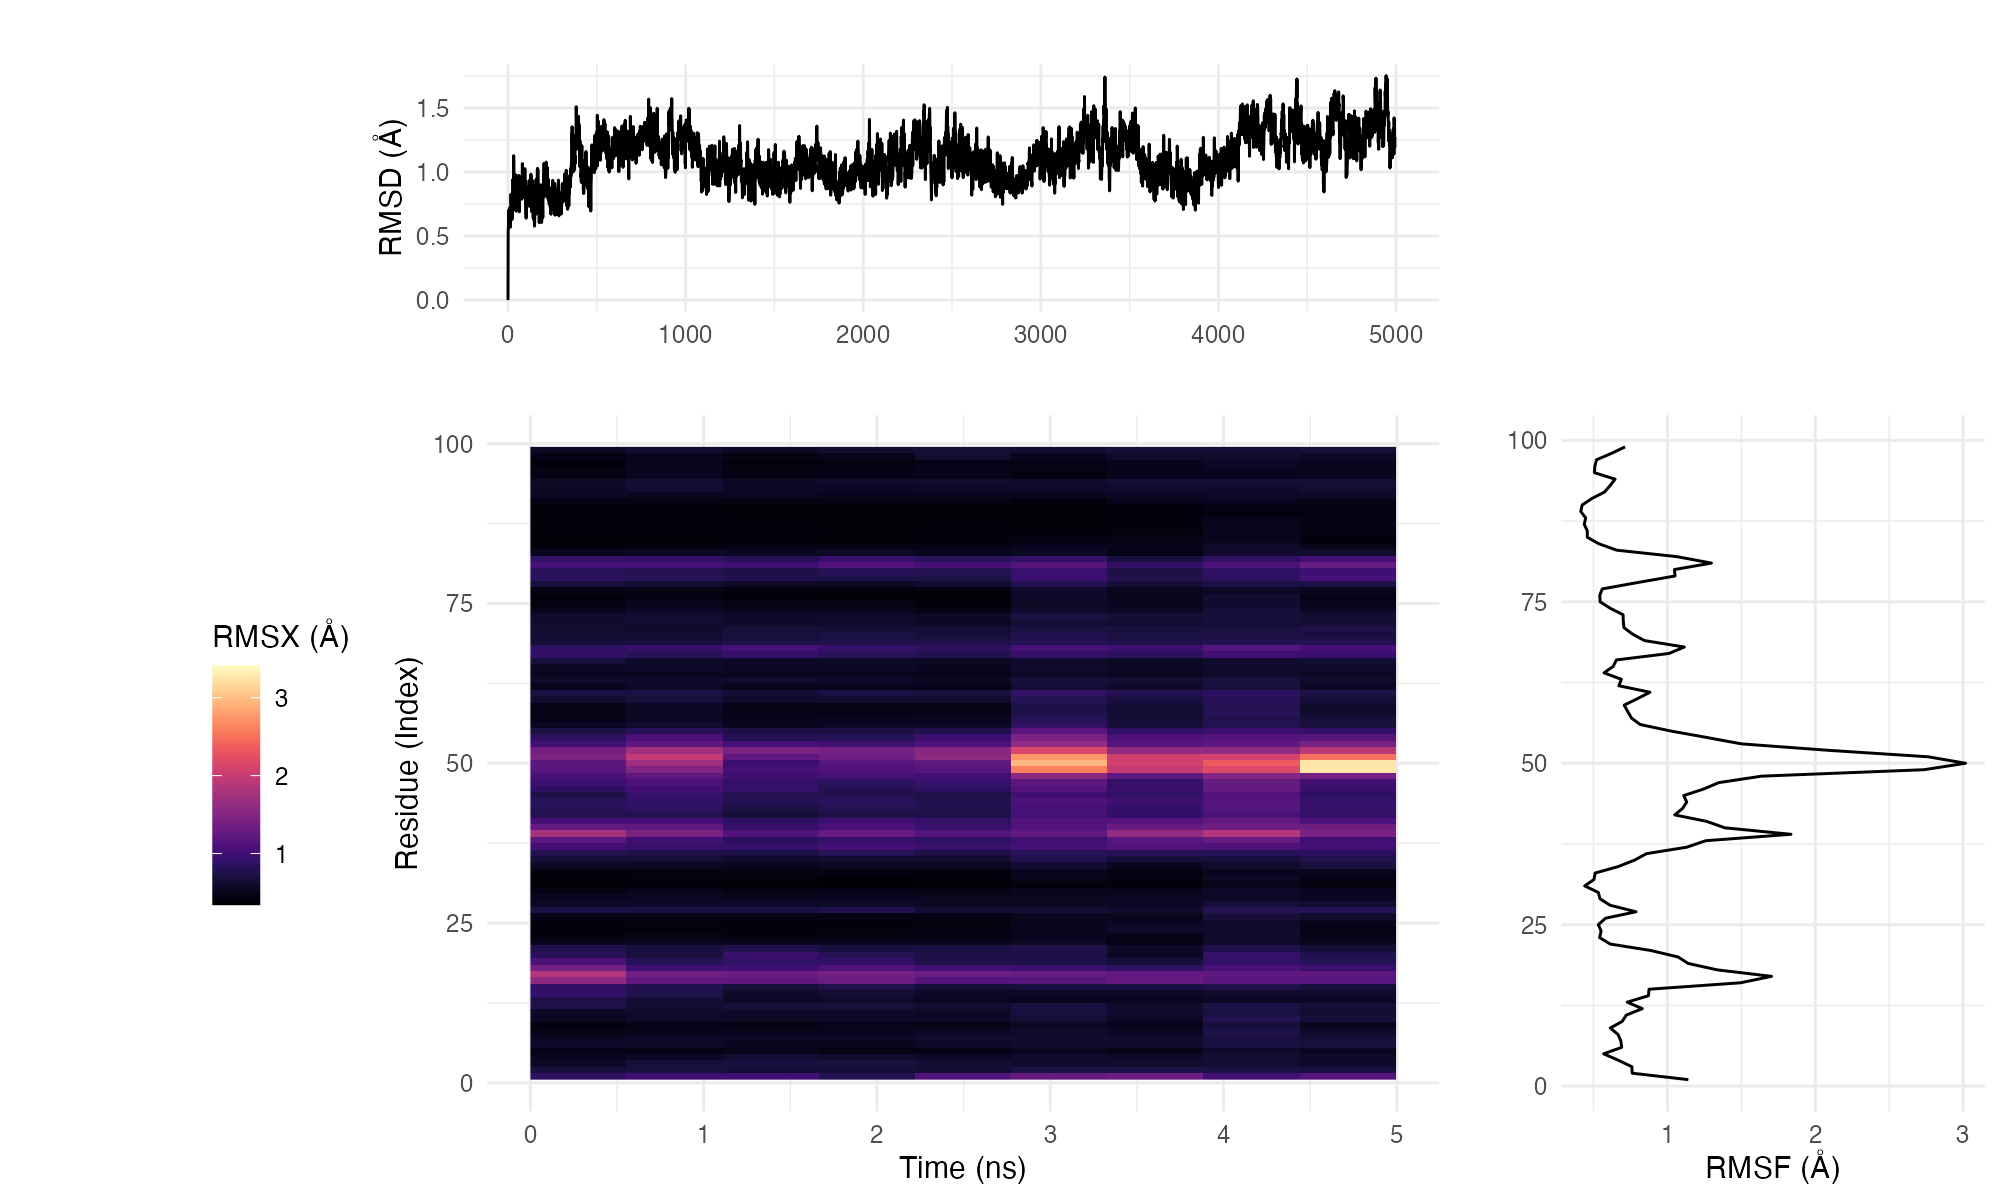

Detected B-factor range: 0.34 - 3.41
[flipbook] macOS bundle candidates (sorted):
   - ChimeraX-1.10.1.app -> /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX  (ver=1.10.1, daily=False)
   - ChimeraX-1.8.app -> /Applications/ChimeraX-1.8.app/Contents/MacOS/ChimeraX  (ver=1.8, daily=False)
   - ChimeraX-1.5.app -> /Applications/ChimeraX-1.5.app/Contents/MacOS/ChimeraX  (ver=1.5, daily=False)
   - ChimeraX_Daily.app -> /Applications/ChimeraX_Daily.app/Contents/MacOS/ChimeraX  (ver=0, daily=True)
[flipbook] Checking ChimeraX candidates (in order):
   - macOS app bundle (ChimeraX-1.10.1.app): /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Using ChimeraX installation: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Launching: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX


In [5]:
run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="magma",         # automatically matches color palette for heatmap and chimeraX structures
    spacingFactor="0.9",     # how much space between the snapshots; 1 is default
    start_frame=0,
    end_frame=None
)

### 5.1 Display the latest FlipBook image (if generated)
If you don't like the orientation, try adjusting it in ChimeraX and rerunning the save command (see the ChimeraX log for details)

In [ ]:
run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    spacingFactor="0.9",
    start_frame=0,
    end_frame=None,   # <--- THIS IS THE ONLY CHANGE
    viewer="vmd"
)


In [ ]:
import glob
from IPython.display import Image, display
imgs = sorted(glob.glob(os.path.join(output_dir_multi, "combined", "*.png")))
if imgs:
    display(Image(filename=imgs[-1]))
else:
    print("No flipbook images found in:", os.path.join(output_dir_multi, "combined"))

### 5.2 Using VMD for FlipBook Visualization
Newer Versions of RMSX/Flipbook support VMD as an alternative to ChimeraX for generating images. To use VMD, set `viewer="vmd"` in the `run_rmsx_flipbook` call. This is still a new feature and may not work on windows machines. You can always visualize them directly with vmd by running something like:

`
$ vmd -dispdev win -e wait_to_load.tcl -args \
path/to/file/slice_1_first_frame.pdb \
path/to/file/slice_2_first_frame.pdb \
path/to/file/slice_3_first_frame.pdb \
path/to/file/slice_4_first_frame.pdb
`

The wait_to_load.tcl script can help solve the issues of VMD loading too quickly before all files are ready. You can also directly call `grid_color_scale_centered_xaxis_hotkeys.tcl`.

Both are located in the vmd_scripts directory.

Check the tcl console for tips on how to adjust the spacing and rotation with VMD hotkeys.

VMD supports extremely high quality rendering with Tachyon.
See the [VMD documentation](https://www.ks.uiuc.edu/Research/vmd/minitutorials/tachyonao/) for details.

In [ ]:

run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",         # automatically matches color palette for heatmap and chimeraX structures
    spacingFactor="0.9",     # how much space between the snapshots; 1 is default
    start_frame=0,
    end_frame=None,
    viewer="vmd"
)

## 6) Interpreting Results

If you want the flanking plots, `triple=True`, RMSX produces:
- **RMSX heatmap** (residue × time slice)
- **RMSD** over time 
- **RMSF** per residue

**Questions to ask:**
1. Which residues/regions show the most flexibility?
2. When do flexibility spikes occur (early/mid/late)?
3. Do multiple intervals of high fluctuation appear?
4. How do these align with functional domains or events (e.g., binding, domain motion)?

---
### Conclusions

You’ve seen how to:
1. Install and configure **RMSX** and **Flipbook**
2. Run single- and multi-chain analyses
3. Generate FlipBook snapshots (optional)
4. Interpret RMSX plots (when/where the biggest changes happen)

For more details, visit the GitHub repo or open an issue with questions.

Feel free to email the primary developer Finn Beruldsen at fpberuld@cougarnet.uh.edu if you need anything else.


### Acknowledgements
We thank the following beta tests for their valuable feedback on this tutorial:
- Mason Kretiv — Texas A&M University
- Helen Ashdown — NIH Biowulf
- John Miles — University of Missouri

/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


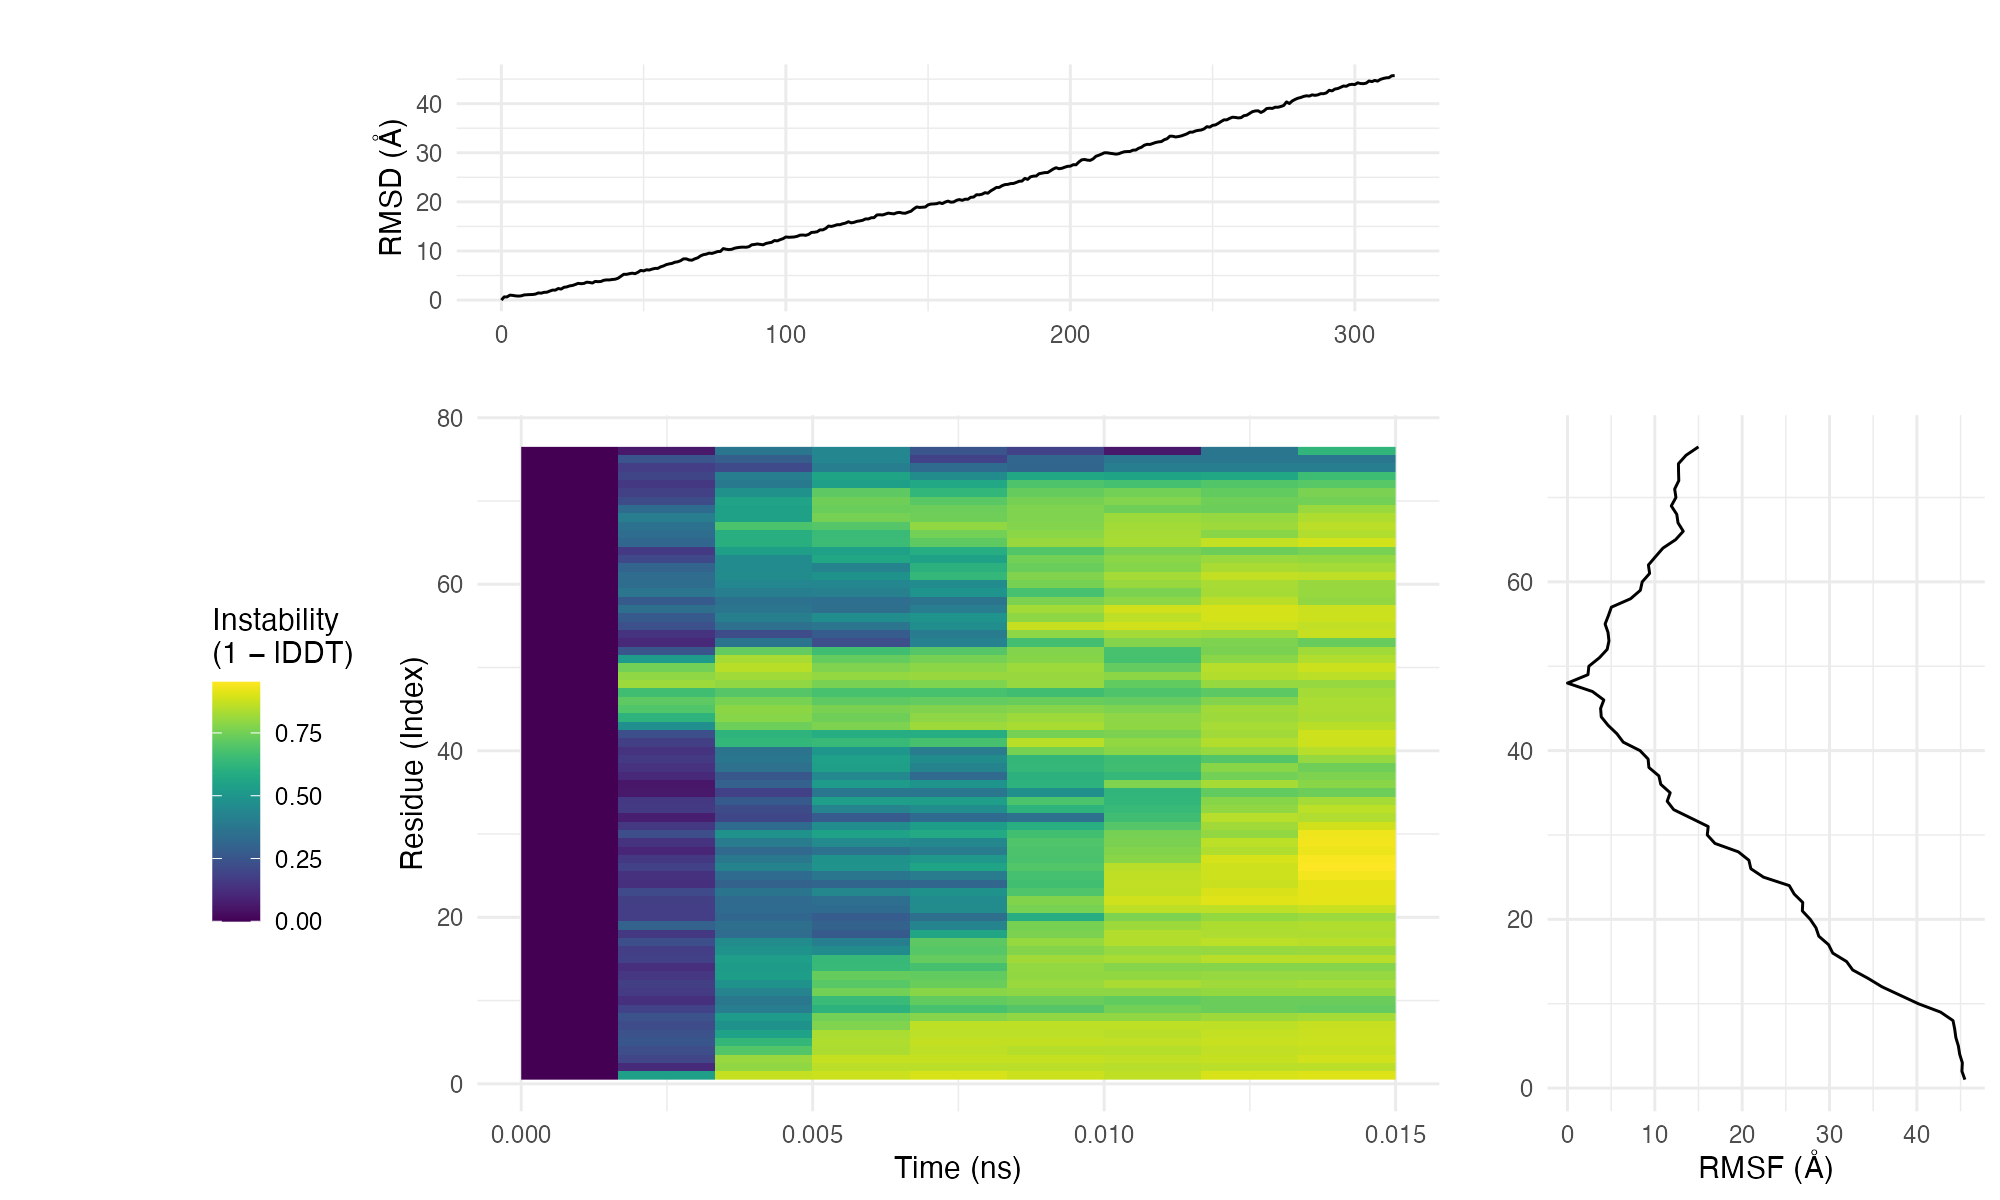

(     ResidueID  ChainID    TimeSlice      RMSX
 633         26        7  slice_9.dcd  0.952381
 634         27        7  slice_9.dcd  0.942308
 632         25        7  slice_9.dcd  0.936170,
    ResidueID  ChainID    TimeSlice  RMSX
 0          1        7  slice_1.dcd   0.0
 1          2        7  slice_1.dcd   0.0
 2          3        7  slice_1.dcd   0.0)

In [5]:
## 3b) Single-Chain lDDT (optional)

from rmsx.addons.lddt import run_lddt_map, run_lddt_flipbook, all_chain_lddt_map

# Put lDDT outputs next to the existing RMSX example
lddt_output_dir = (test_dir / "example_uqb_lddt").as_posix()

run_lddt_map(
    topology_file=pdb_file,  # same PDB as RMSX demo
    trajectory_file=dcd_file,  # same trajectory
    output_dir=lddt_output_dir,  # new folder for lDDT outputs
    num_slices=9,  # same slicing pattern as RMSX demo
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,  # lDDT heatmap + RMSD + RMSF
    overwrite=True,
    palette="viridis",  # choose your favorite cmap
    chain_sele="7",  # same chain as RMSX demo
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    summary_n=3,
    manual_length_ns=None,
    log_transform=False,  # lDDT is already 0–1
    inclusion_radius=15.0,  # local neighborhood radius (Å)
    thresholds=(0.5, 1.0, 2.0, 4.0),  # classic lDDT thresholds

)






/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


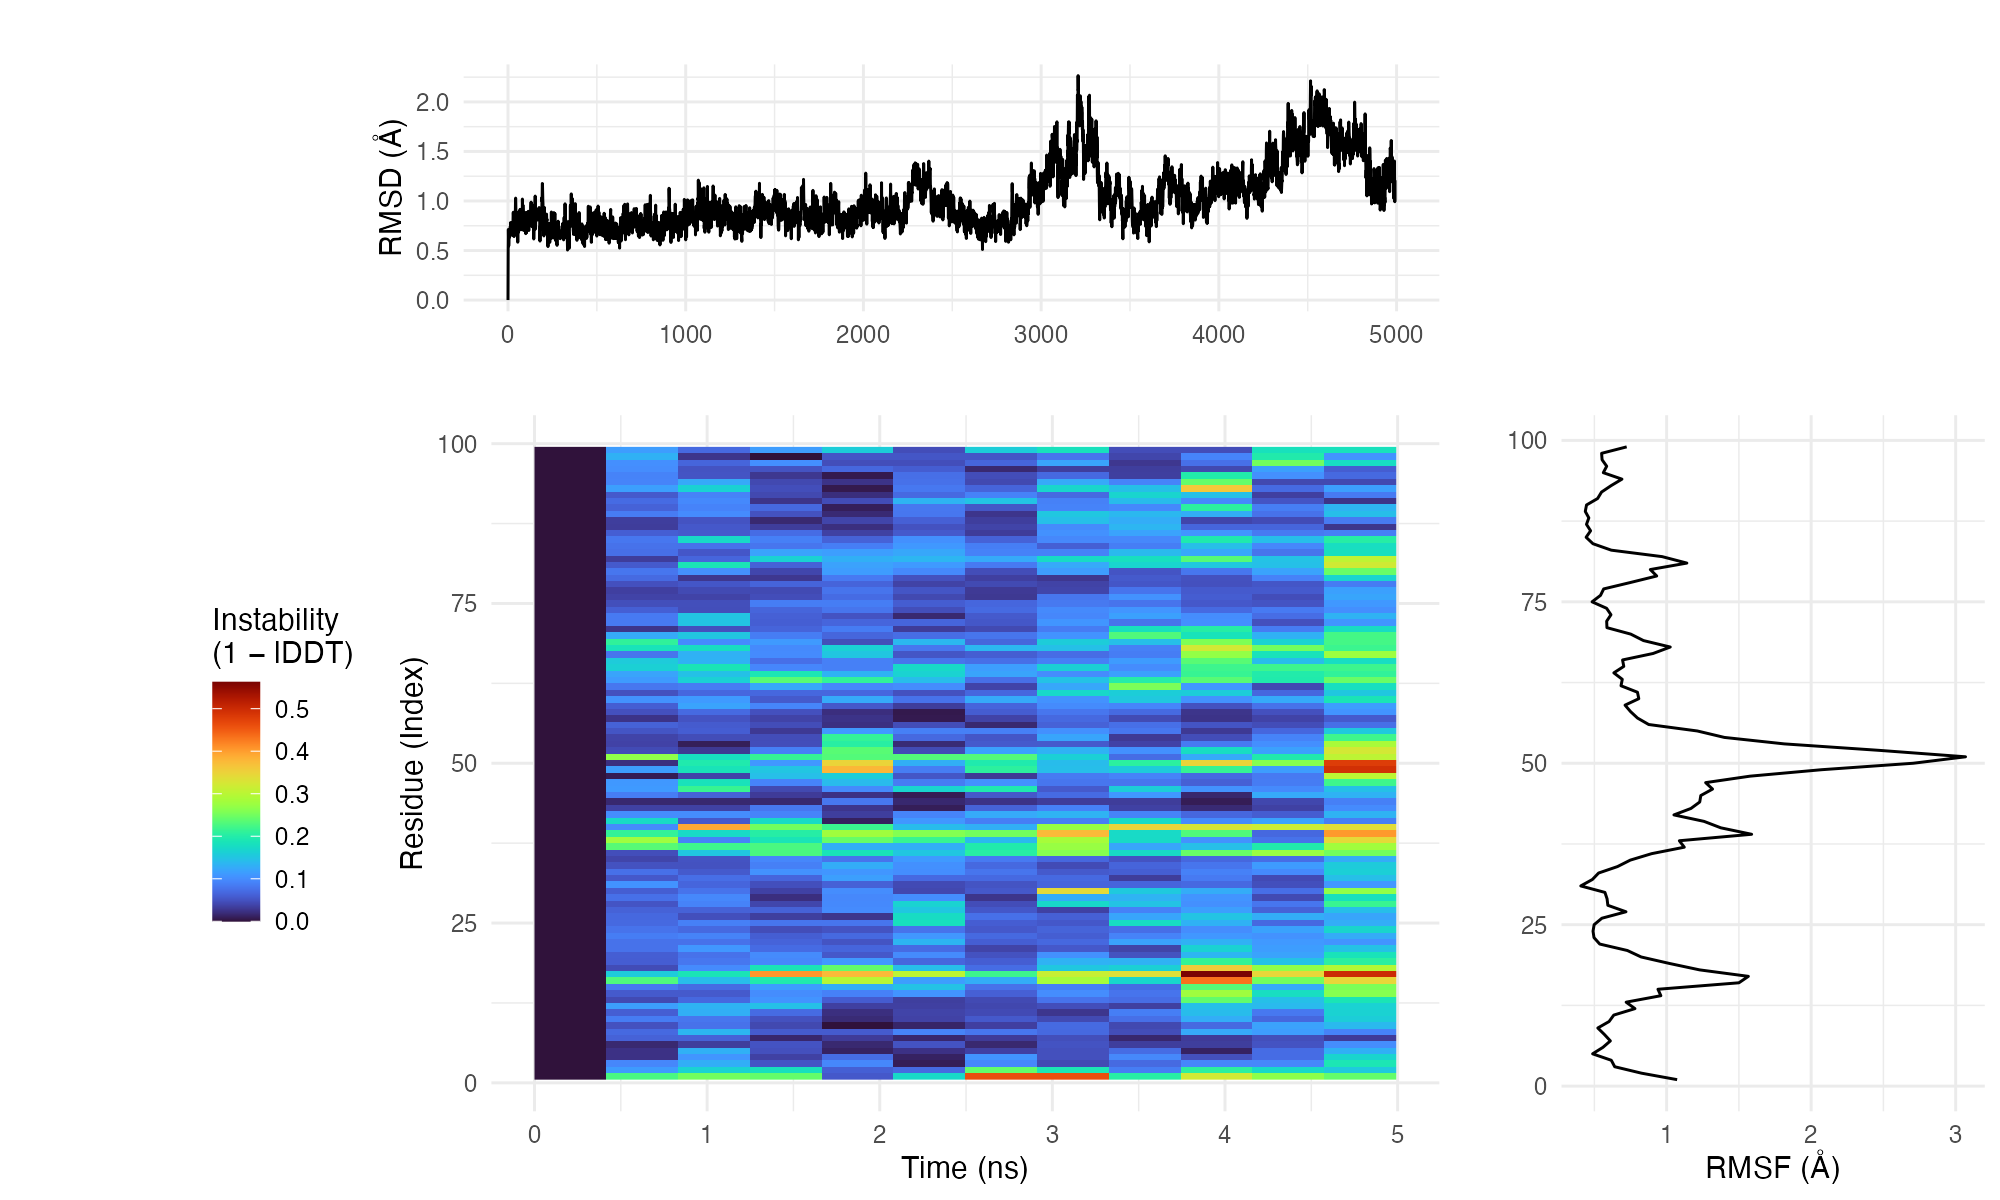

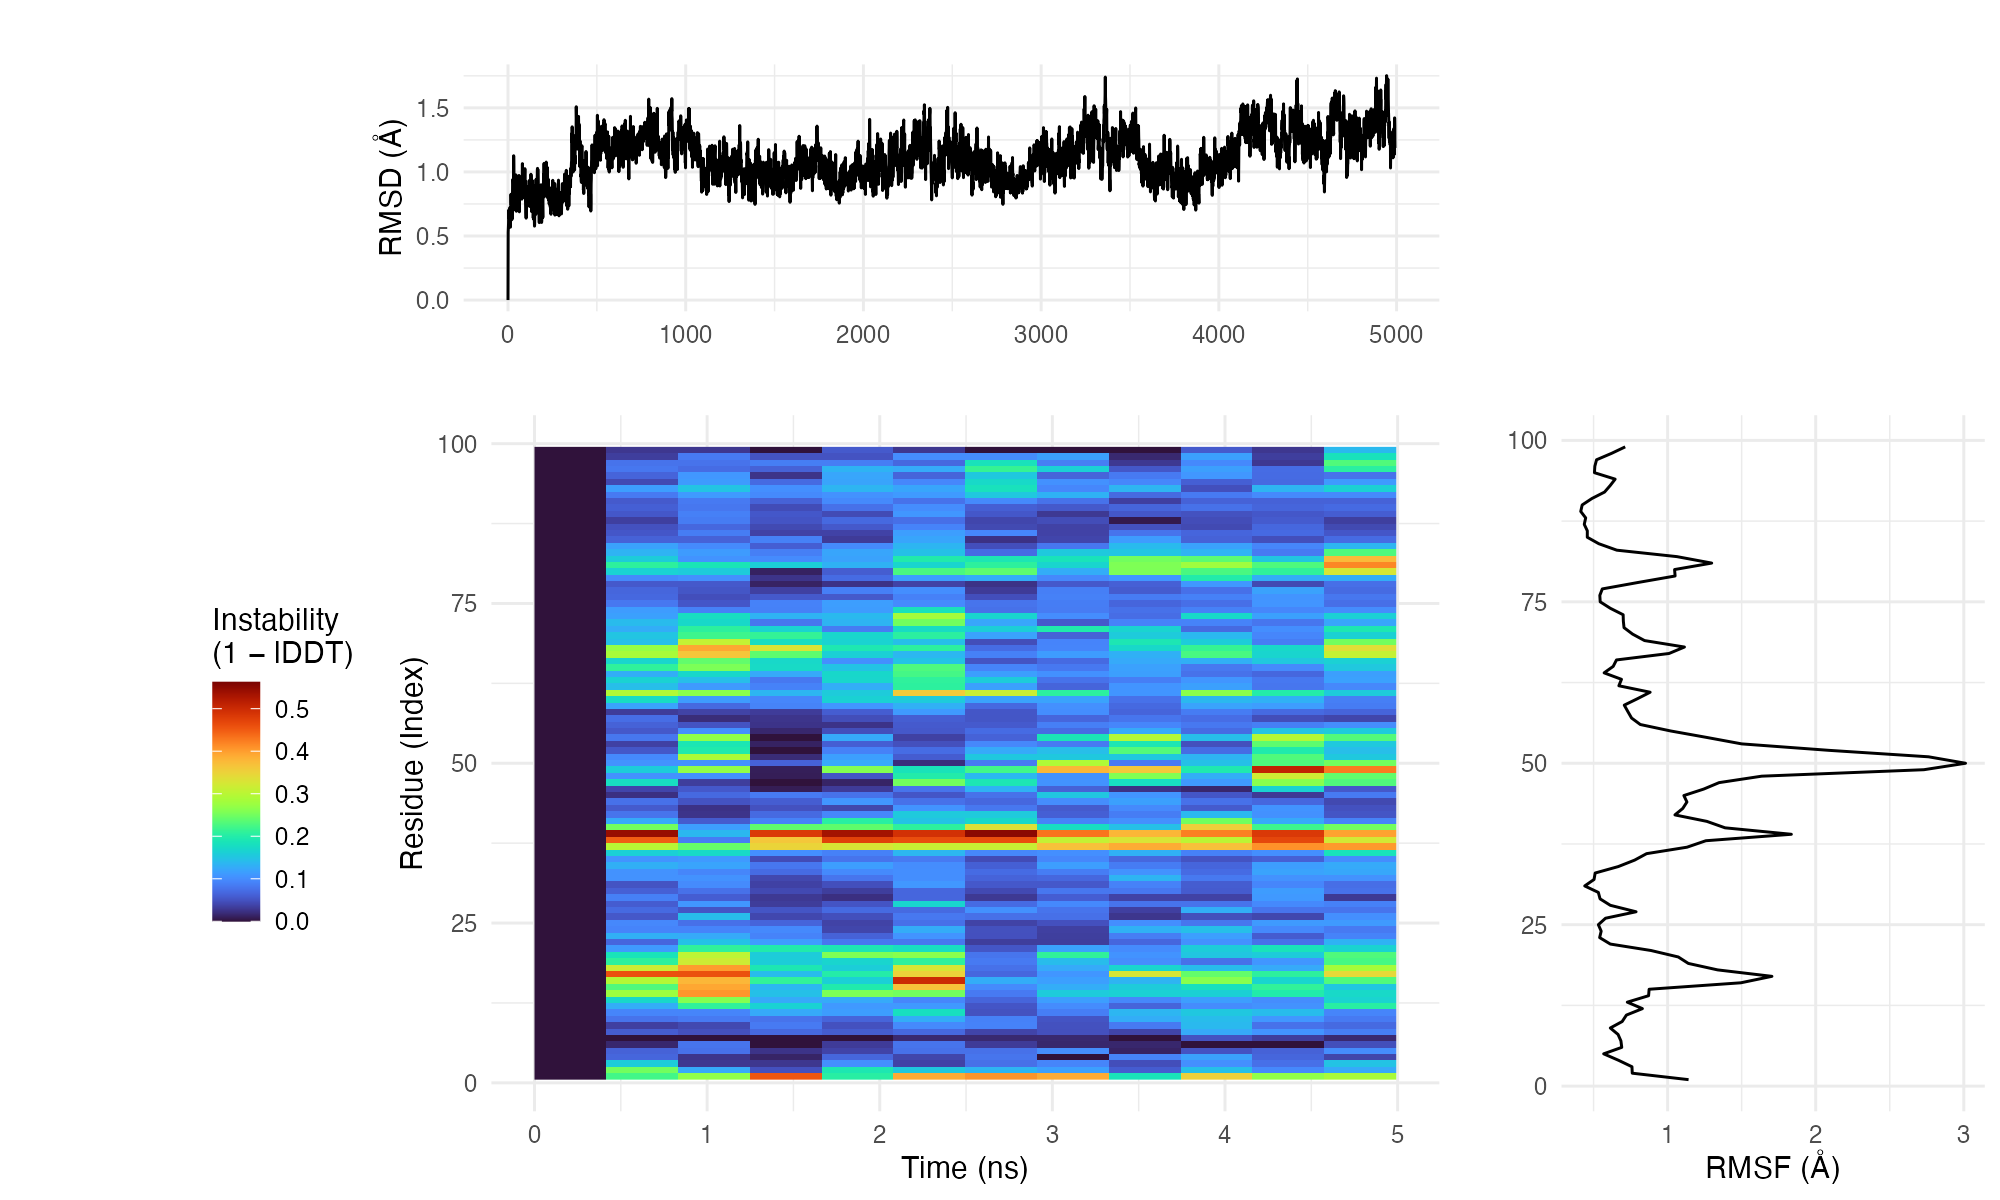

Combined lDDT PDBs for Flipbook live in: /Users/finn/Documents/GitHub/rmsx/test_files/protease_lddt/combined


In [10]:
## 4b) Multi-Chain lDDT Maps (protease)

# New output folder for multi-chain lDDT (keep separate from RMSX/shift outputs)
lddt_output_dir_multi = (test_dir / "protease_lddt").as_posix()

combined_lddt_dir = all_chain_lddt_map(
    topology_file=pdb_file_multi,  # protease backbone
    trajectory_file=traj_file_multi,  # short_protease_backbone.dcd
    output_dir=lddt_output_dir_multi,
    num_slices=12,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=None,
    sync_color_scale=True,  # shared colorbar across chains
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    log_transform=False,
    inclusion_radius=15.0,
    thresholds=(0.5, 1.0, 2.0, 4.0),
)

print("Combined lDDT PDBs for Flipbook live in:", combined_lddt_dir)


/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


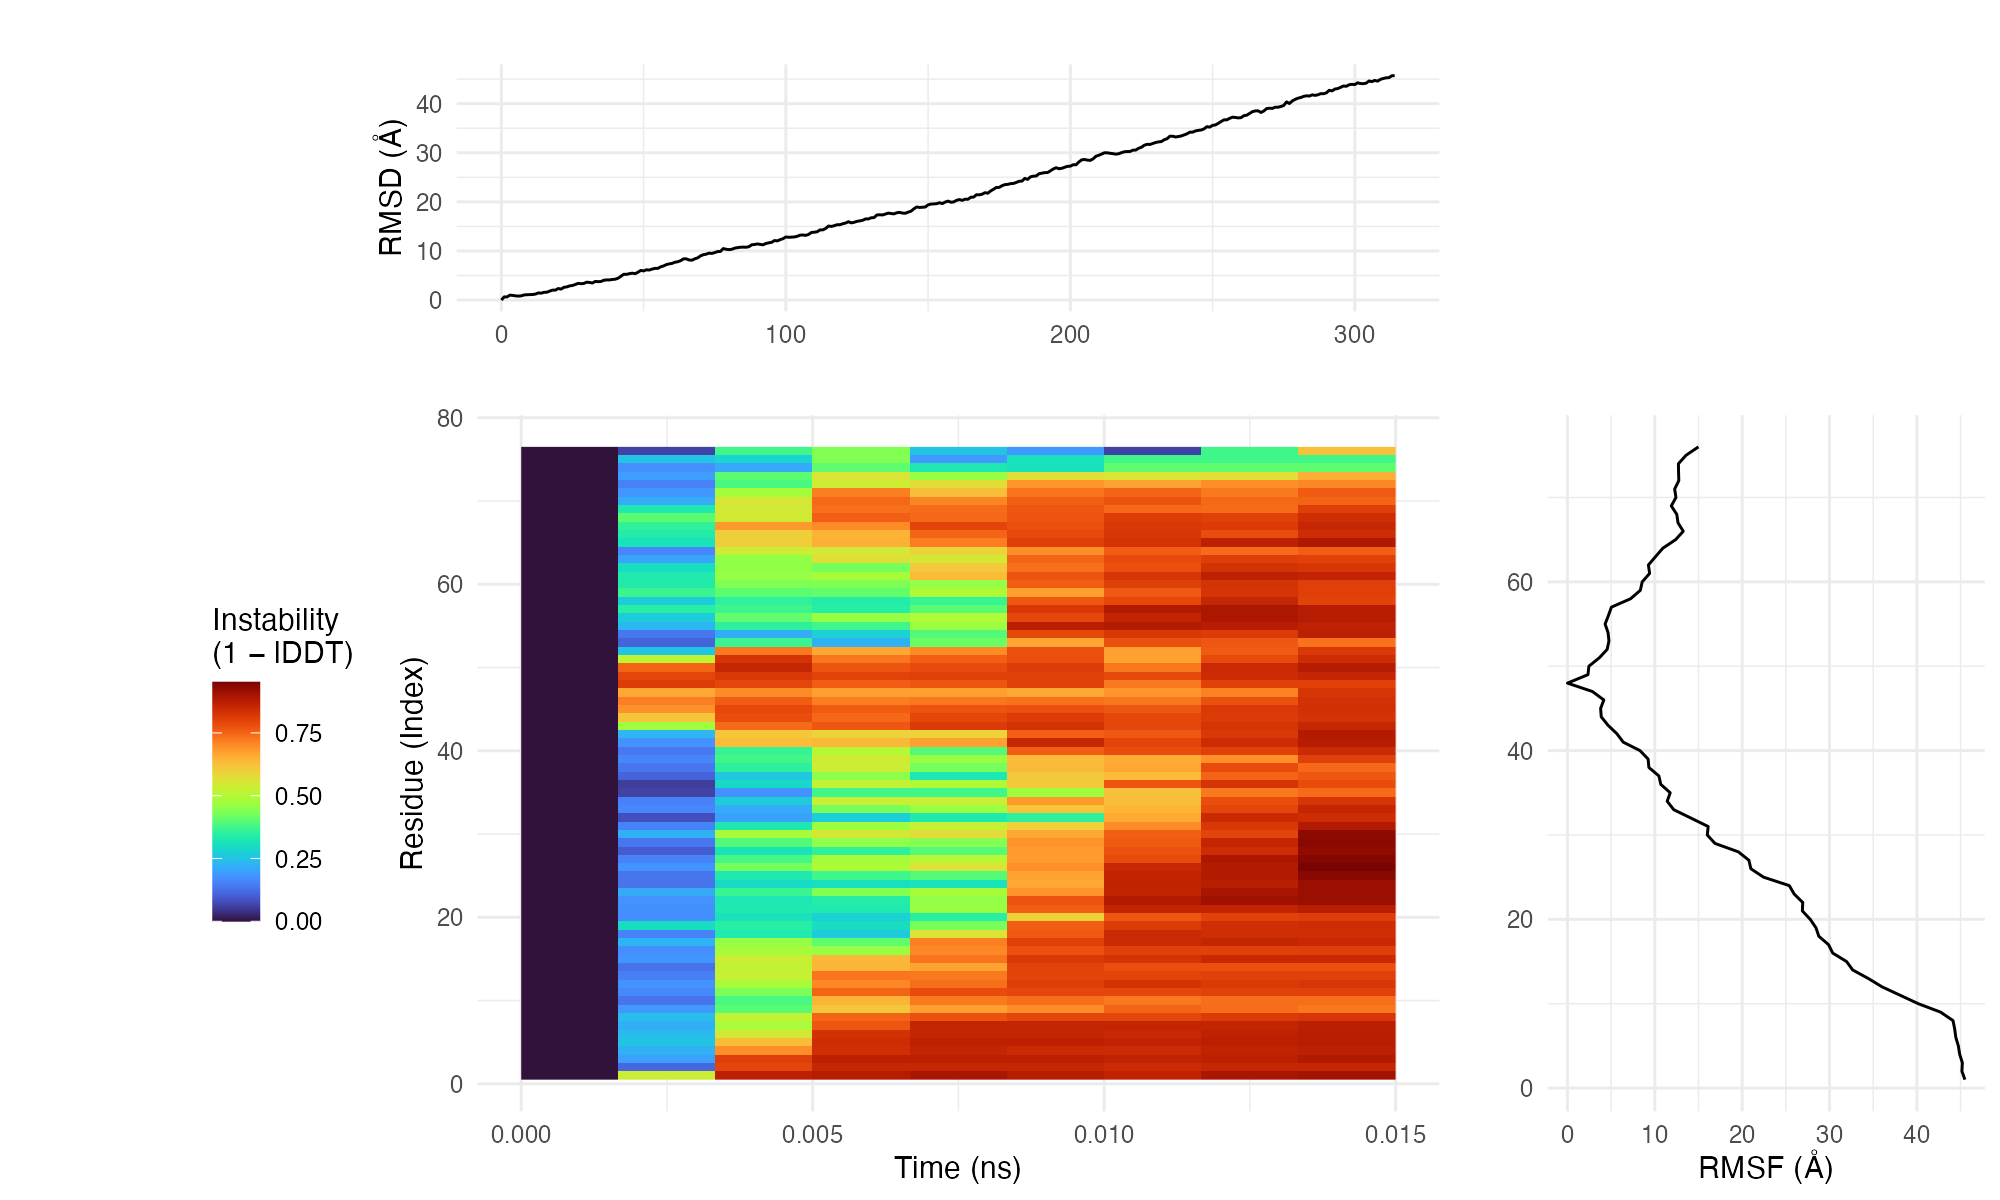

Detected B-factor range: 0.00 - 0.95
[flipbook] macOS bundle candidates (sorted):
   - ChimeraX-1.10.1.app -> /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX  (ver=1.10.1, daily=False)
   - ChimeraX-1.8.app -> /Applications/ChimeraX-1.8.app/Contents/MacOS/ChimeraX  (ver=1.8, daily=False)
   - ChimeraX-1.5.app -> /Applications/ChimeraX-1.5.app/Contents/MacOS/ChimeraX  (ver=1.5, daily=False)
   - ChimeraX_Daily.app -> /Applications/ChimeraX_Daily.app/Contents/MacOS/ChimeraX  (ver=0, daily=True)
[flipbook] Checking ChimeraX candidates (in order):
   - macOS app bundle (ChimeraX-1.10.1.app): /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Using ChimeraX installation: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Launching: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX


'/Users/finn/Documents/GitHub/rmsx/test_files/protease_lddt/chain_7_lddtmap'

In [9]:
## 5b) Multi-Chain lDDT Flipbook (protease)

# Same idea as the run_rmsx_flipbook demo, but using lDDT instead of RMSX
run_lddt_flipbook(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=lddt_output_dir_multi,  # same parent as above
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # matches lDDT heatmap
    spacingFactor="0.9",  # spacing between tiled models
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    sync_color_scale=True,  # enforce global lDDT scale
    flipbook_min_bfactor=None,  # auto-scale unless you want fixed
    flipbook_max_bfactor=None,
    log_transform=False,
    inclusion_radius=15.0,
    thresholds=(0.5, 1.0, 2.0, 4.0),
    viewer="ChimeraX",  # or "ChimeraX" / "chimerax"
    extra_commands=None,  # e.g. extra ChimeraX commands
)


/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/Users/finn/miniconda3/envs/testing_ngl/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


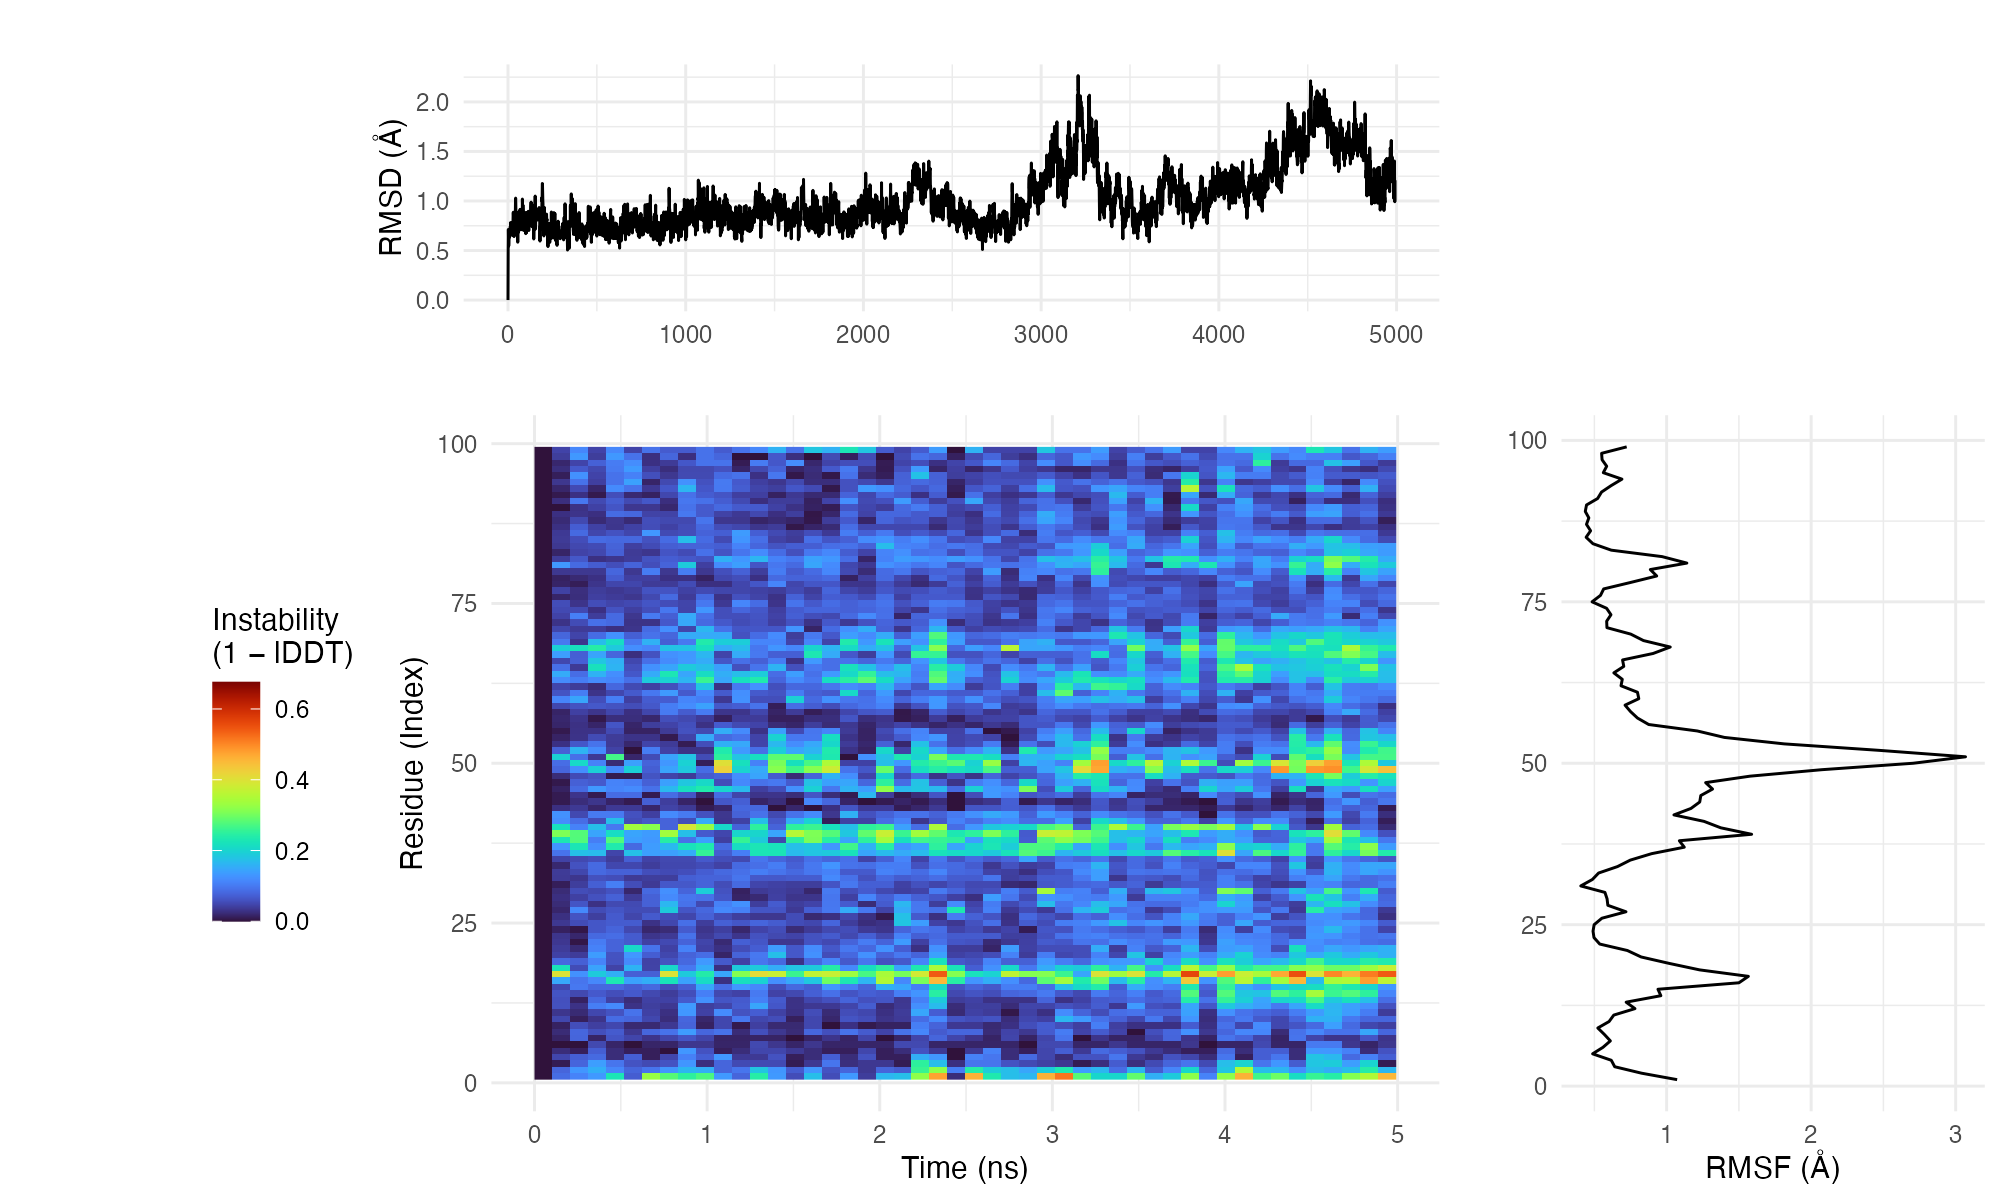

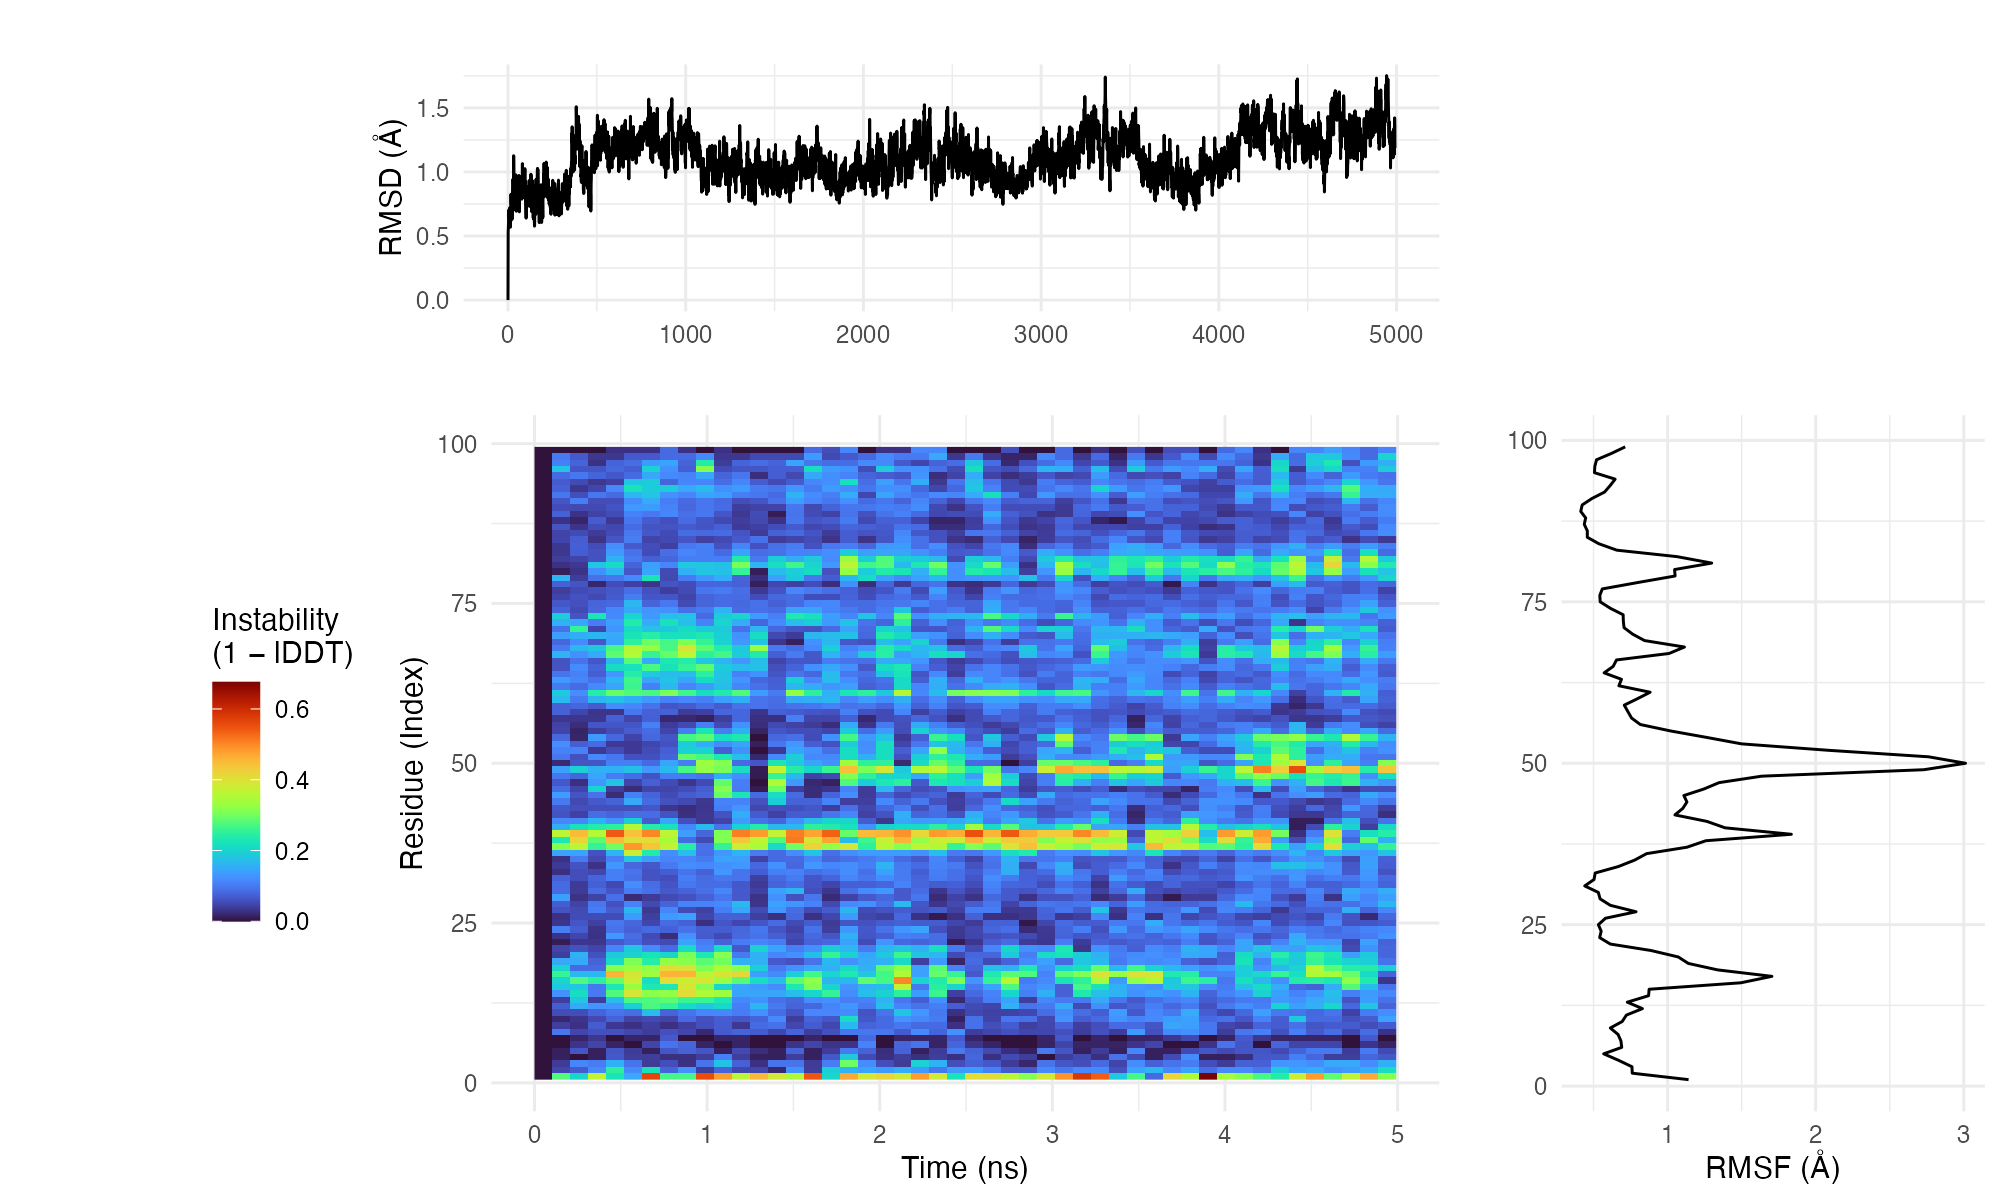

Detected B-factor range: 0.00 - 0.68
[flipbook] macOS bundle candidates (sorted):
   - ChimeraX-1.10.1.app -> /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX  (ver=1.10.1, daily=False)
   - ChimeraX-1.8.app -> /Applications/ChimeraX-1.8.app/Contents/MacOS/ChimeraX  (ver=1.8, daily=False)
   - ChimeraX-1.5.app -> /Applications/ChimeraX-1.5.app/Contents/MacOS/ChimeraX  (ver=1.5, daily=False)
   - ChimeraX_Daily.app -> /Applications/ChimeraX_Daily.app/Contents/MacOS/ChimeraX  (ver=0, daily=True)
[flipbook] Checking ChimeraX candidates (in order):
   - macOS app bundle (ChimeraX-1.10.1.app): /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Using ChimeraX installation: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Launching: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX


'/Users/finn/Documents/GitHub/rmsx/test_files/protease_lddt/combined'

In [12]:
## 5b) Multi-Chain lDDT Flipbook (protease)

# Same idea as the run_rmsx_flipbook demo, but using lDDT instead of RMSX
run_lddt_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=lddt_output_dir_multi,  # same parent as above
    num_slices=48,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # matches lDDT heatmap
    spacingFactor="0.9",  # spacing between tiled models
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    sync_color_scale=True,  # enforce global lDDT scale
    flipbook_min_bfactor=None,  # auto-scale unless you want fixed
    flipbook_max_bfactor=None,
    log_transform=False,
    inclusion_radius=15.0,
    thresholds=(0.5, 1.0, 2.0, 4.0),
    viewer="ChimeraX",  # or "ChimeraX" / "chimerax"
    extra_commands=None,  # e.g. extra ChimeraX commands
)
